# Machine Learning: AllLife Bank Personal Loan Campaign

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
import pandas as pd
import numpy as np

import matplotlib.pylab as plt
%matplotlib inline

import seaborn as sns

# Library to split data
from sklearn.model_selection  import train_test_split


# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    ConfusionMatrixDisplay,
    make_scorer,
    confusion_matrix
)

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Loading the dataset

In [ ]:
# read the data
df = pd.read_csv('/content/drive/MyDrive/Loan_Modelling.csv')
pd.set_option('display.max_rows', 500)
# returns the first 5 rows
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## Data Overview

* Observations
* Sanity checks

In [ ]:
print("There are", df.shape[0], 'rows and', df.shape[1], "columns.")

There are 5000 rows and 14 columns.


In [ ]:
# summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


#### **Observations**

*   There are 13 int and 1 float numerical datatypes of data in the column.
*   We can drop ID and need to change ZIPCode to category.

In [ ]:
#removing ID column and assigning to new data frame so that we are not affecting original dataset
df_new=df.drop(columns='ID',axis=1)
df_new.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


**Observations**:

Column Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online	CreditCard and ZIPCode datatype needs to be changed to category.


In [ ]:
#list of columns in new dataframe
df_new.columns

Index(['Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='object')

In [ ]:
#assigning columns with categorical values to a variable
ctg_col=[ 'Education',  'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard','ZIPCode']

In [ ]:
#converting datatype of column with categorical values to category datatype
df_new[ctg_col]=df_new[ctg_col].astype('category')
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   ZIPCode             5000 non-null   category
 4   Family              5000 non-null   int64   
 5   CCAvg               5000 non-null   float64 
 6   Education           5000 non-null   category
 7   Mortgage            5000 non-null   int64   
 8   Personal_Loan       5000 non-null   category
 9   Securities_Account  5000 non-null   category
 10  CD_Account          5000 non-null   category
 11  Online              5000 non-null   category
 12  CreditCard          5000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 294.1 KB


In [ ]:
#looking for missing values or null values in all columns
df_new.isnull().sum()

Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

#### **Observations**

There are no null values.


In [ ]:
#looking for duplicates values in all columns
df_new.duplicated().sum()

0

#### **Observations**

There are no duplicates.


In [ ]:
#Summary of the dataset
df_new.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.134600,11.415189,0.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0


#### **Observations**

**Age** - The average age of customer is 45. The distribution seems normal.

**Family** - The average family size of customer is 2.

**Experience** - The average working experience of customer is 20.

**Income** - The average income of customer is 73.774. Std of 46.03 indicates wide range of income.

**CC_Avg** - The average credit card spending of customer is 1.93 with a std of 1.75 incdicates varying spending habits among customers.

**Mortgage** - The average mortgage value of customer is $56.49, with a large standard deviation, indicating that while some individuals have no mortgage, others have significant amounts.


## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

Idenitfying unique and total number of unique values to idenitify data anomaly

In [ ]:
# Print unique values for each column
for col in df_new:
    print(f"Unique values in column \033[1m\033[4m'{col}'\033[0m: {df_new[col].unique()}")
    print('******************************')
    print(f"Number of Unique values in column \033[1m\033[4m'{col}'\033[0m: {df_new[col].nunique()}")
    print('----------------------------------------------------------------------------------------')

Unique values in column 'Age': [25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
******************************
Number of Unique values in column 'Age': 45
----------------------------------------------------------------------------------------
Unique values in column 'Experience': [ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
******************************
Number of Unique values in column 'Experience': 47
----------------------------------------------------------------------------------------
Unique values in column 'Income': [ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15 

####**Observations**

There are 2 columns that has values that needs further attention.

*   Column Experience has values -1,-2 and -3
*   Column ZIPCode has 467 unique values. Based on the document shared with Data Scientist, I have 2 options. Below are those option:

1. First number indicates region and next 2 numbers is major post office. I will try splitting zipcode with those 2 options to see if we can reduce number of unique values.
2.  Use an external library (uszipcode) to extract more features to derive insights.



#####**Treating column experience:**

In [ ]:
df_new[df_new['Experience'] < 0].groupby('Experience')['Experience'].value_counts()

Experience
-3     4
-2    15
-1    33
Name: count, dtype: int64

Experience has 52 records that has negative values. Don't have a way to confirm if its a data entry or a valid entry. If its a mistake it should be validated and restricted in UX.

In [ ]:
df_new['Experience']=np.where(df_new['Experience']  < 0, -df_new['Experience'],df_new['Experience'] )


I have assumed this is data entry error and treated in a way to replace negative value with positive value. That is -1 will be replaced with 1.

In [ ]:
df_new[df_new['Experience'] < 0].groupby('Experience')['Experience'].value_counts()

Series([], Name: count, dtype: int64)

#####**Treating column ZIPCode:**

In [ ]:
df_new['ZIPCode']=df_new['ZIPCode'].astype(str)
df_new['ZIPCode'].str[0].nunique()

1

Unique first number of zipcode in our data indicates the customers are all from same national region.

In [ ]:
df_new['ZIPCode']=df_new['ZIPCode'].astype(str)
df_new['ZIPCode'].str[0:3].nunique()

57

In next step I have included the next 2 numbers that is 2nd and 3rd number in the zipcode which indicates sectional center or Large City. The unique value in the data comes to 57.

In [ ]:
df_new['ZIPCode_Mod']=df_new['ZIPCode'].str[0:3]


**Observations**:

I have created a new column ZIPCode_Mod to store first 3 characters of zipcode.

As an alternate I wanted add city, county and state to the dataframe. I tried using uszipcode library that was suggested in the document. I encountered and error - AttributeError: module 'sqlalchemy_mate' has no attribute 'ExtendedBase'. This prevented me from proceeding further. Tried different versions of sqlmate but still ran into this error.

After searching web I encountered pgeocoder library and will to incorporate it.

In [ ]:
!pip install pgeocode

In [ ]:
import pgeocode

nomi = pgeocode.Nominatim('us')
zipinfo=nomi.query_postal_code("99001")
zipinfo.county_name,zipinfo.place_name

('Spokane', 'Airway Heights')

Testing the library to see columns and its result.

In [ ]:
import pgeocode

nomi = pgeocode.Nominatim('us')

# Function to get county information
def get_county(zipcode):
    try:
        zipinfo=nomi.query_postal_code(zipcode)
        return pd.Series([zipinfo.place_name,zipinfo.county_name,zipinfo.state_name])
        #return zipinfo.place_name,zipinfo.county_name,zipinfo.state_name
    except:
        return None

# Apply the function to the 'zipcode' column and create a new 'county','state' column
df_new[['city','county','state']] = df_new['ZIPCode'].apply(get_county)



In [ ]:
df_new['city'].nunique()

244

The total number of unique cities in the data set are 244

In [ ]:
df_new['county'].nunique()

38

The total number of unique counties in the data set are 38

In [ ]:
df_new['state'].nunique()

1

The total number of unique states in the data set is 1. This indicates all the data are from state of California.

In [ ]:
df_new.drop(columns=['ZIPCode','city','county','state'], inplace=True)


#### **Observations**

After taking deepdive with Zipcode by creating new columns ZIPCode_Mod, city, county and state I have made decision to drop ZIPCode, city, county and state. ZIPCode_Mod will be a better representation since it will have national region and big post office or a sectoinal center that are combined to create a unique feature. The ZIPCode is also part of the data and don't have to rely on 3rd party library. There is always a chance that City and County names are not unique across states. Having ZIPCode_Mod will better address this shortcoming in the model. Alternately I could combine columns together to form a unique value. For simplicity I will use ZIPCode_Mod.



In [ ]:
df_new.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,ZIPCode_Mod
0,25,1,49,4,1.6,1,0,0,1,0,0,0,911
1,45,19,34,3,1.5,1,0,0,1,0,0,0,900
2,39,15,11,1,1.0,1,0,0,0,0,0,0,947
3,35,9,100,1,2.7,2,0,0,0,0,0,0,941
4,35,8,45,4,1.0,2,0,0,0,0,0,1,913


In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   Family              5000 non-null   int64   
 4   CCAvg               5000 non-null   float64 
 5   Education           5000 non-null   category
 6   Mortgage            5000 non-null   int64   
 7   Personal_Loan       5000 non-null   category
 8   Securities_Account  5000 non-null   category
 9   CD_Account          5000 non-null   category
 10  Online              5000 non-null   category
 11  CreditCard          5000 non-null   category
 12  ZIPCode_Mod         5000 non-null   object  
dtypes: category(6), float64(1), int64(5), object(1)
memory usage: 303.6+ KB


In [ ]:
#converting datatype of ZIPCode_Mod with categorical values to category datatype
df_new['ZIPCode_Mod']=df_new['ZIPCode_Mod'].astype('category')

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

In [ ]:
#assigning columns with categorical values to a variable
ctg_col=[ 'Education',  'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard','ZIPCode_Mod']

In [ ]:
#assigning columns with numerical values to a variable
num_col= ['Age', 'Family','Experience', 'Income',  'CCAvg','Mortgage']

## Univariate Analysis.

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()

###**Univariate analysis on numerical columns**

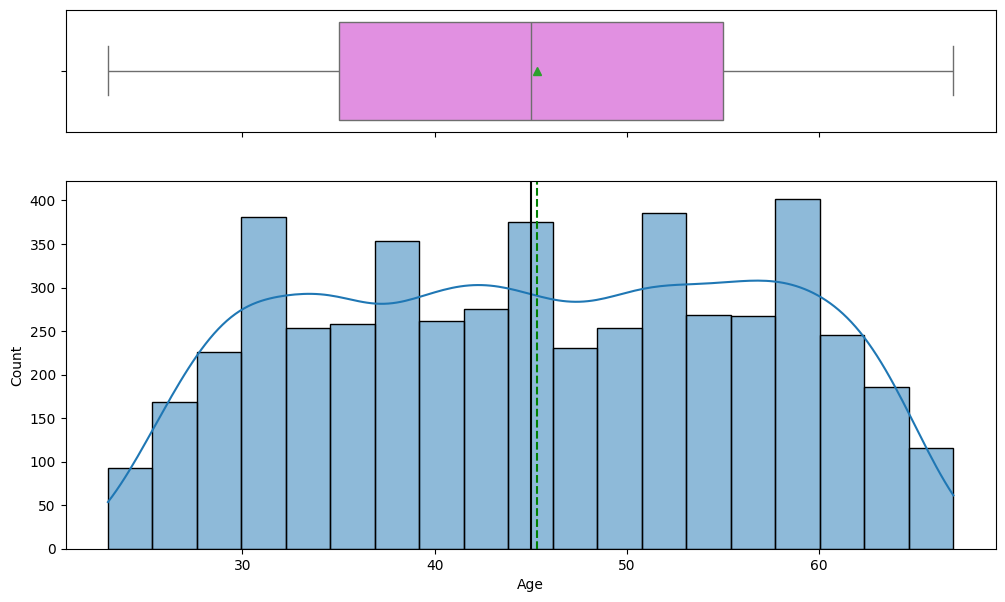

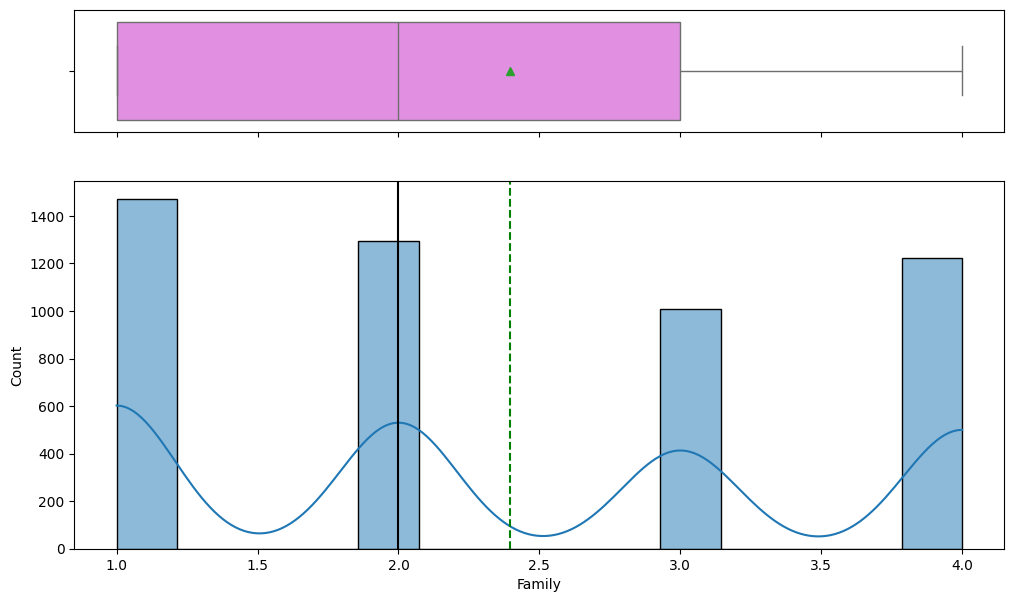

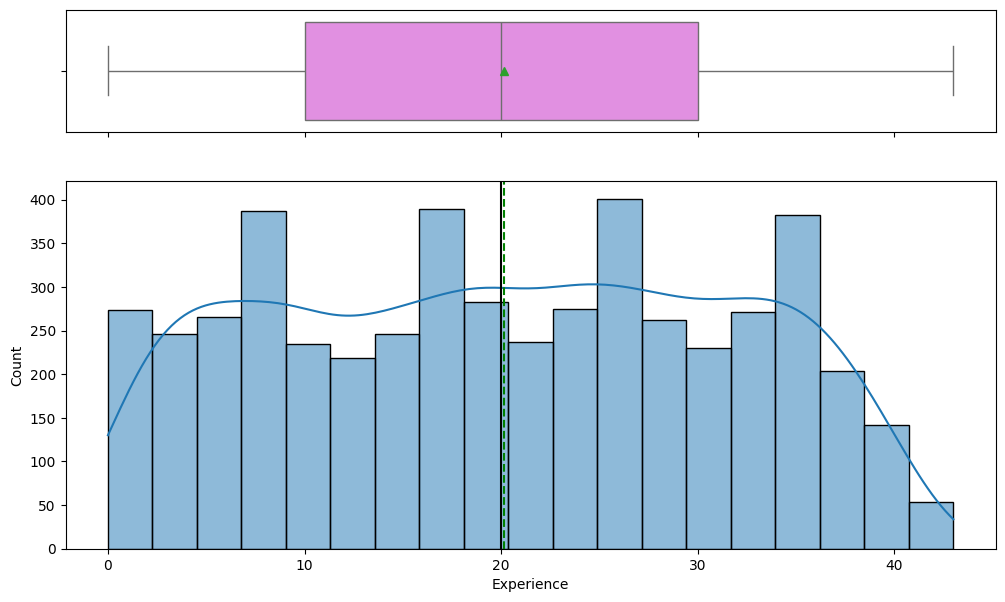

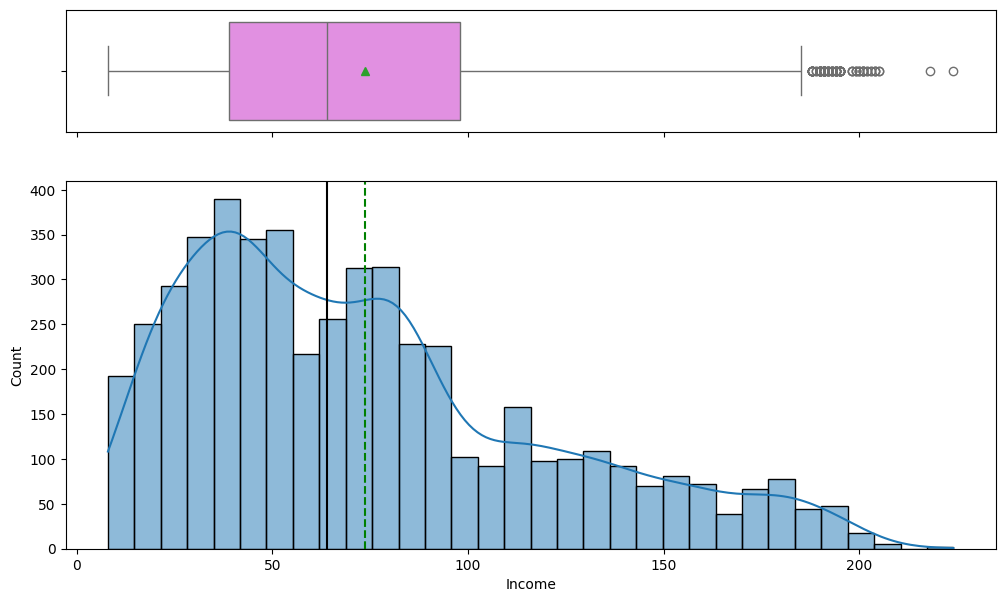

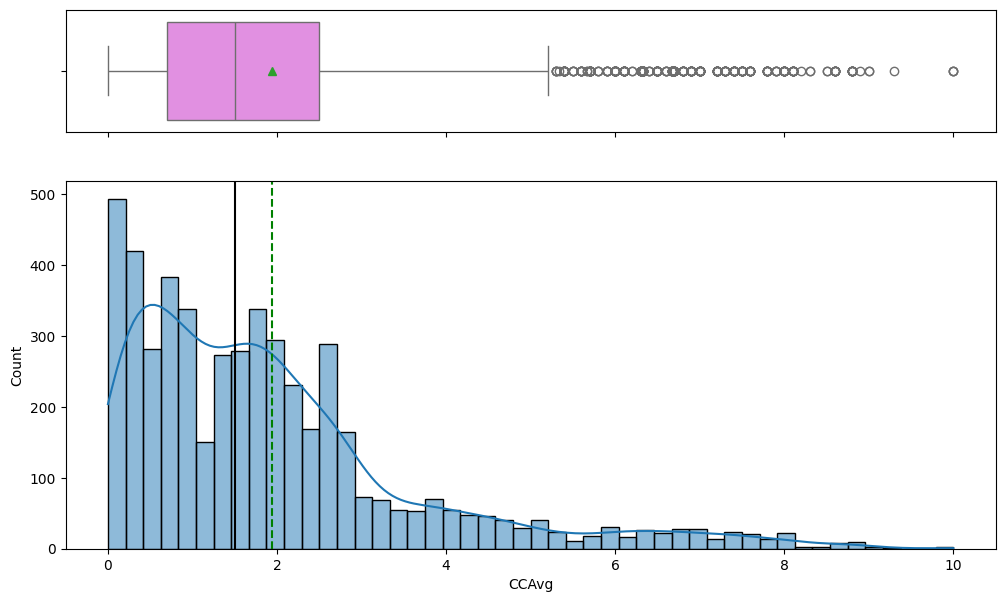

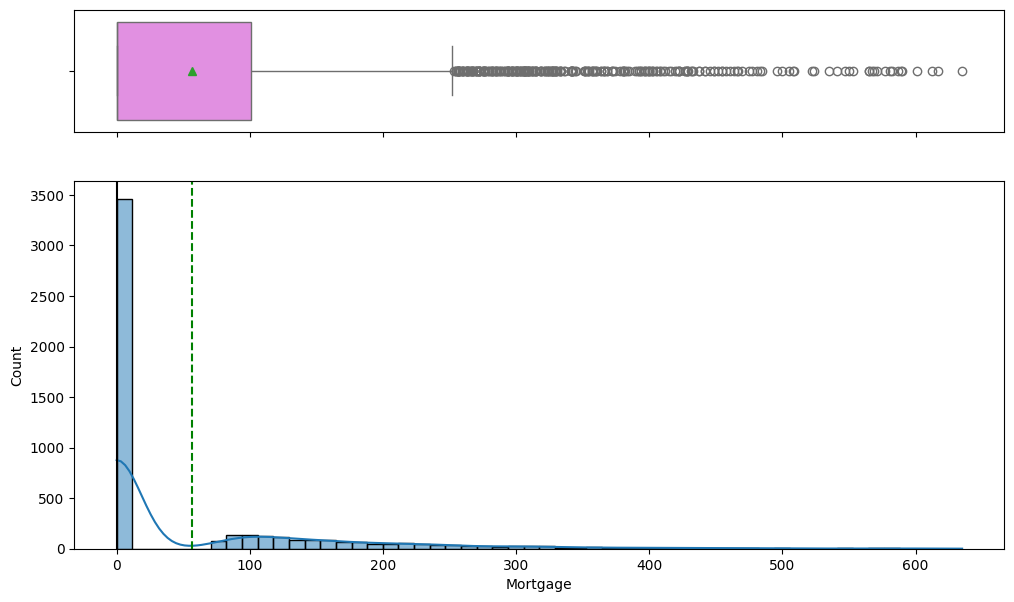

In [ ]:
#performing univariate analysis on numerical columns
for col in df_new[num_col]:
  histogram_boxplot(df_new, col, kde=True)

#### **Observations**

**Age** - Mean and Median are around 45. The distribution has several spikes in 350 to 400 caused by age group in 30-32,37-39,43-45,51-53 and 58-60 but approximately uniform distrubition.

**Family** - There is slight right skewness in the distribution. Most customers are single followed by a family of 2.

**Experience** - Mean and Median are around 20. The distribution has several spikes above 350 cause by customers who have 7-9,16-18,24-26 and 34-36 years of experience. There is a slight right skewness at tail end.

**Income** - Median is less than Mean indicating slight right skewness and evident in the distribution. There are outliers in the data that are above Q3 + 1.5 * IQR

**CC_Avg** - Median is less than Mean indicating slight right skewness and evident in the distribution. There are outliers in the data that are above Q3 + 1.5 * IQR

**Mortgage** - Median is far less than Mean indicating heavy right skewness and evident in the distribution. There are outliers in the data that are above Q3 + 1.5 * IQR. There are close to 3400 customers who don't have mortgage.

I will not be treating **outliers** in Income,CC_Avg and Mortgage as they are actual values.

###**Categorical analysis on numerical columns**

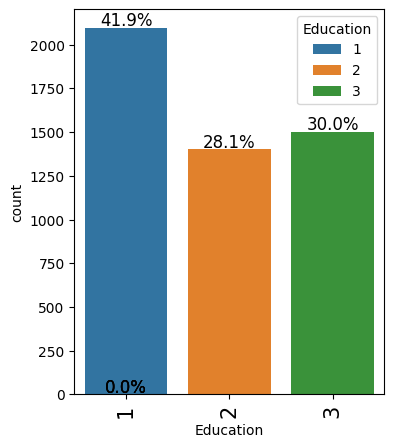

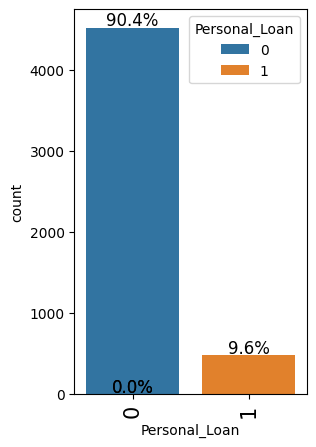

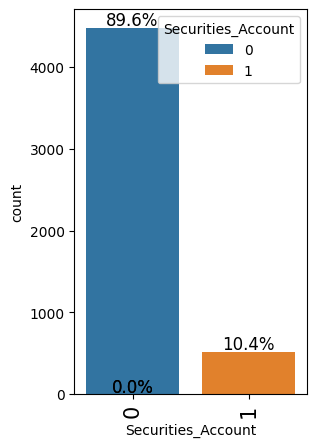

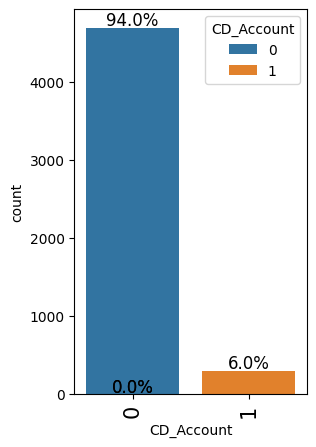

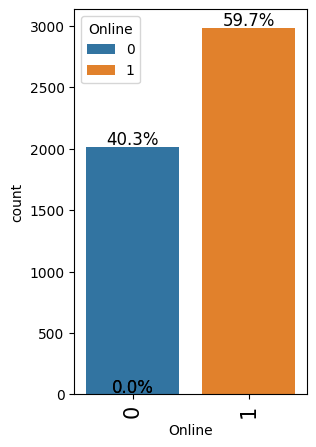

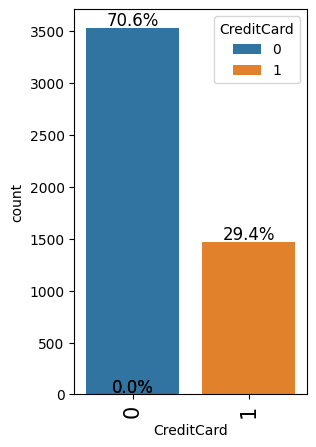

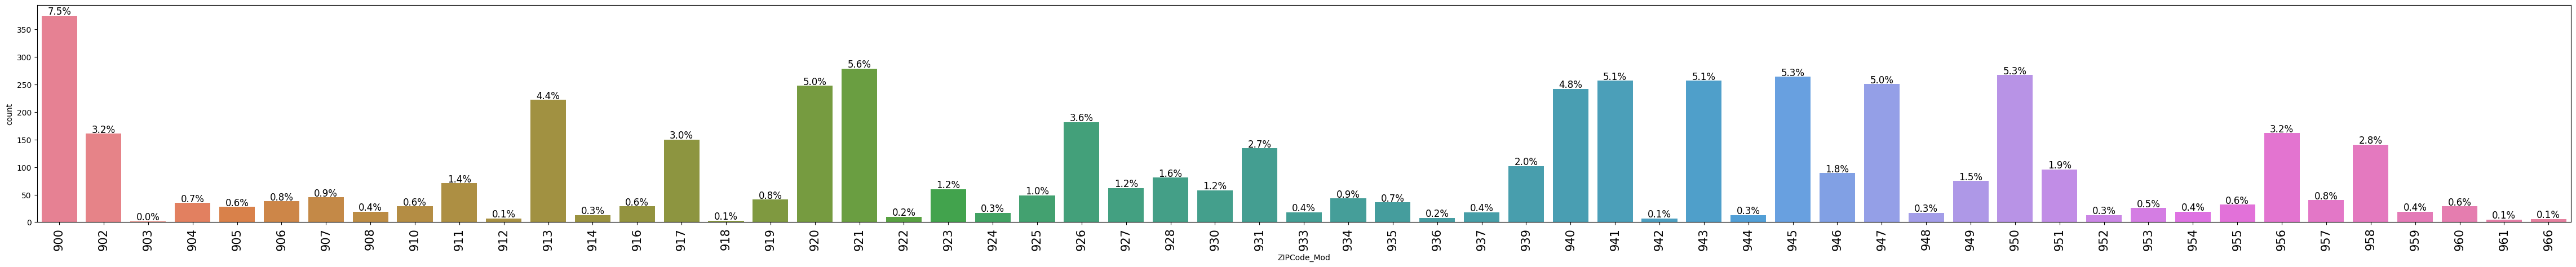

In [ ]:
#performing univariate analysis on categorical columns
for col in df_new[ctg_col]:
  labeled_barplot(df_new, col, perc=True, n=None)

#### **Observations**

**Education** - 41.9% customers are undergrads followed by 30% of advanced/professional and closely followed by 28.1% of graduates.

**Securities_Account** - 10.4% of customers have securities account.

**CD_Account** - Only 6% of customers have CD Account.

**Online** - 59.7% of customers are using online banking.

**CreditCard** - 29.4% of customers are using credit card.

**ZIPCode_Mod** - '900' ZIPCode_Mod area has 7.5% of customers.

In [ ]:
df_new['ZIPCode_Mod'].value_counts().nlargest(15).sum()

3458

Out of 5000 customer 3458 are from 15 ZIPCode_Mod locations. It is around 70%

## Bivariate Analysis.

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], hue=target)#palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        hue=target
        #palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

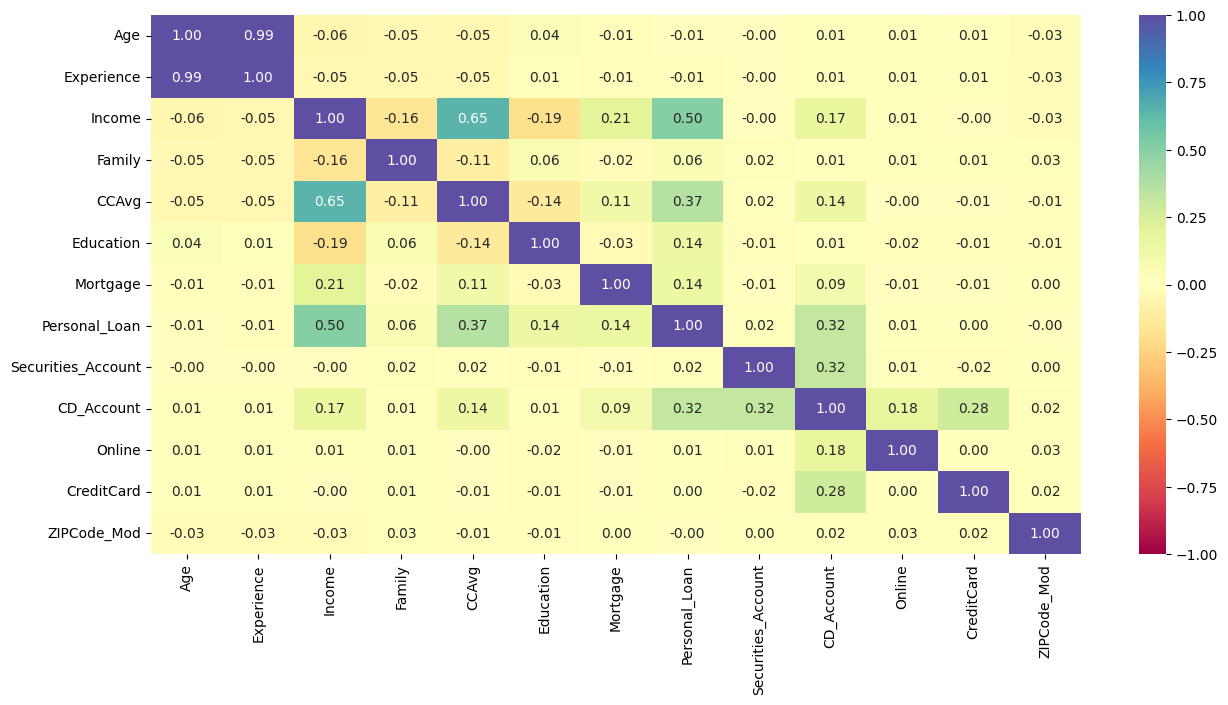

In [ ]:
#Correlation check with heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(df_new.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#### **Observations**

**Age** and *Experience* have high positive correlation.

**Family** has slight negative correlation with *credit card average and income*.

**CC_Avg** and *income* have positive correlation. This indicates that as income increases customers spend using credit card. Similar positive correlation exists with *personal loan*. There is slight negative correlation with *Family and Education*.

**Income** and *Personal Loan* has positive correlation.

**CD_Account** has slight positive correlation with *Personal Loan, credit card and Securities account*

Further investigation will be done



Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


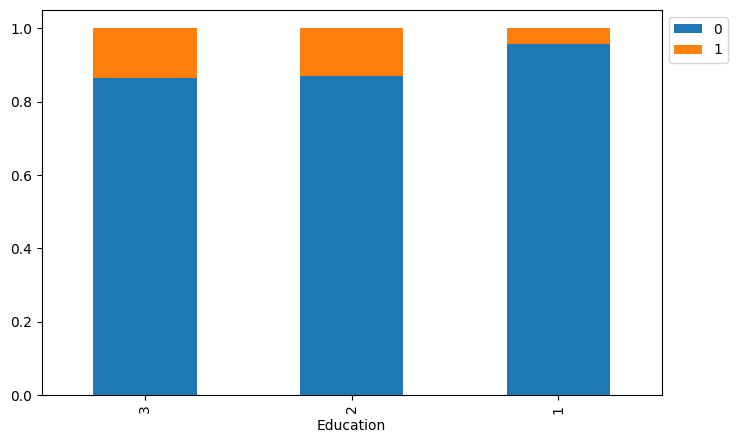

Personal_Loan     0    1   All
Personal_Loan                 
1                 0  480   480
All            4520  480  5000
0              4520    0  4520
------------------------------------------------------------------------------------------------------------------------


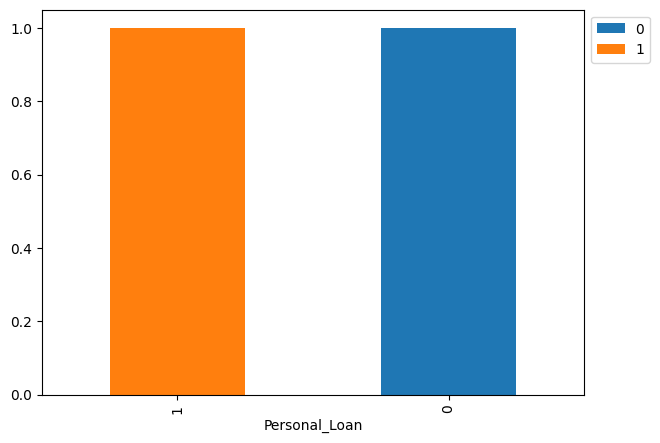

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


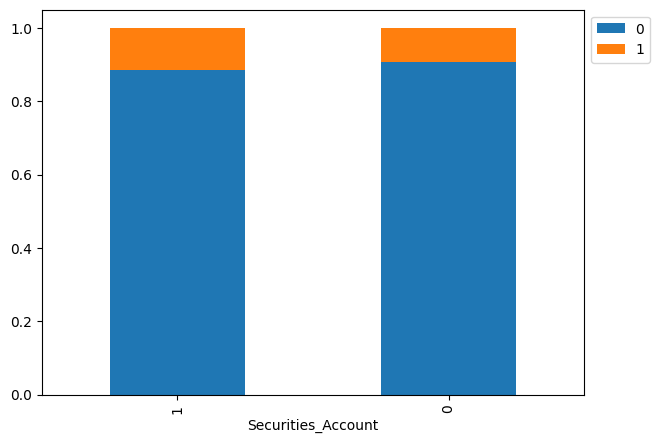

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


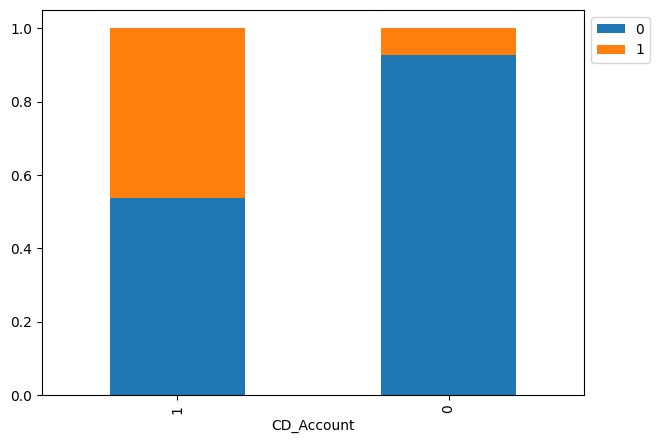

Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


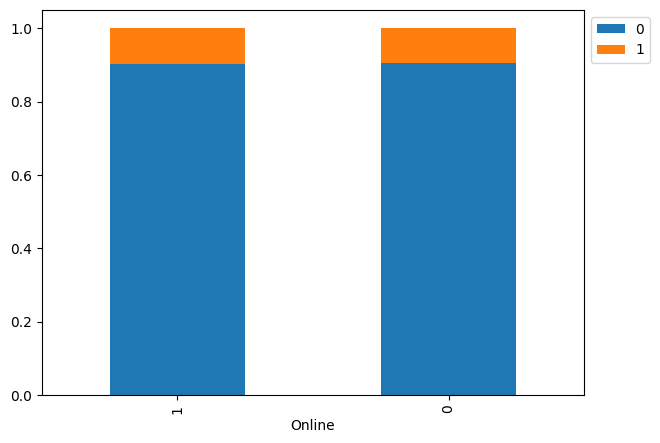

Personal_Loan     0    1   All
CreditCard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


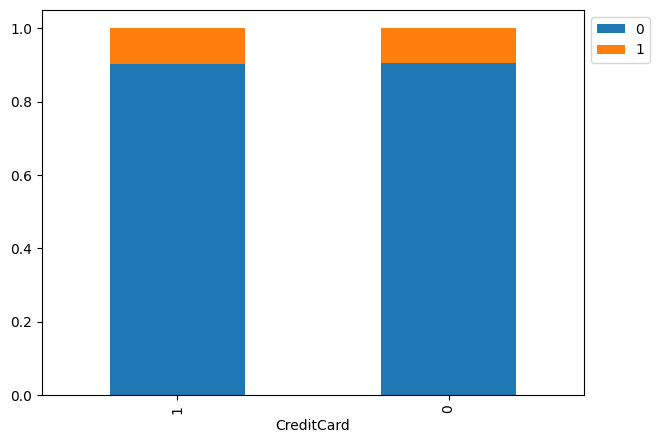

Personal_Loan     0    1   All
ZIPCode_Mod                   
All            4520  480  5000
900             337   38   375
950             231   36   267
920             216   32   248
943             228   29   257
947             224   27   251
913             198   24   222
945             241   23   264
921             256   23   279
926             160   22   182
941             238   19   257
940             224   18   242
902             147   14   161
958             129   12   141
939              91   11   102
951              85   11    96
949              64   11    75
911              61   10    71
930              49    9    58
931             125    9   134
917             142    8   150
956             154    8   162
946              83    6    89
957              35    5    40
906              33    5    38
934              38    5    43
935              32    4    36
928              77    4    81
919              37    4    41
927              58    4    62
925     

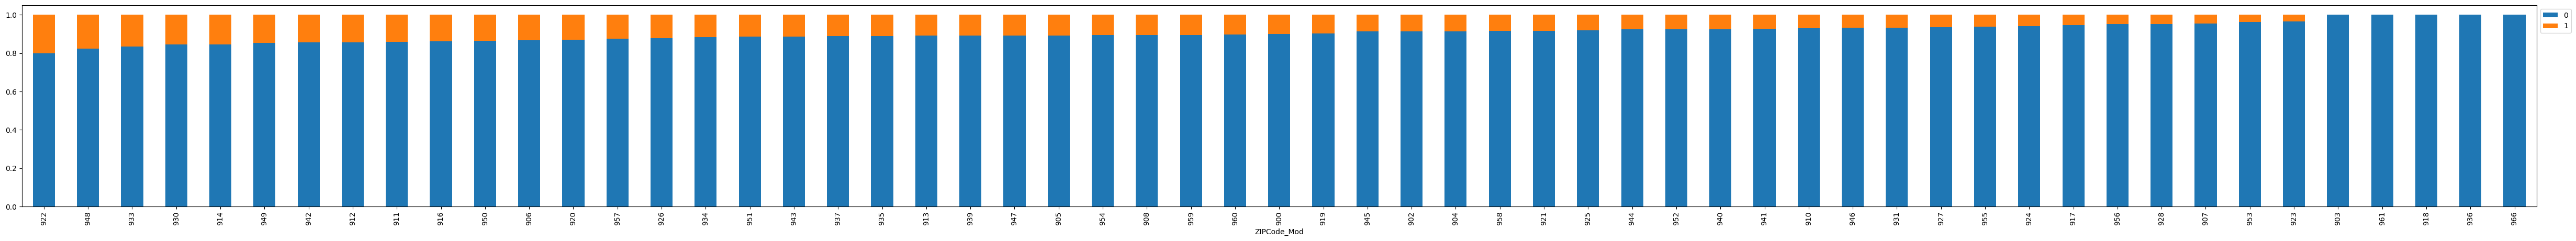

In [ ]:
#The bank is trying to expand their personal loan business. That will be our target variable. We will compare it with other variables to get more insights

for col in df_new[ctg_col]:
  stacked_barplot(df_new, col, 'Personal_Loan')

#### **Observations**

*   80% of Customers who have personal loans are graduates and advance degrees  comapred to 20% of undergrads. But undergrads are larger customer base of the bank.
*   46% of Cusotmers who have CD account have personal loan accounts.
*   60% of Customers who are online customers have personal loans but only 11% of online users have applied for personal loan.
*   28% of Customers who have credit cards have personal loans.



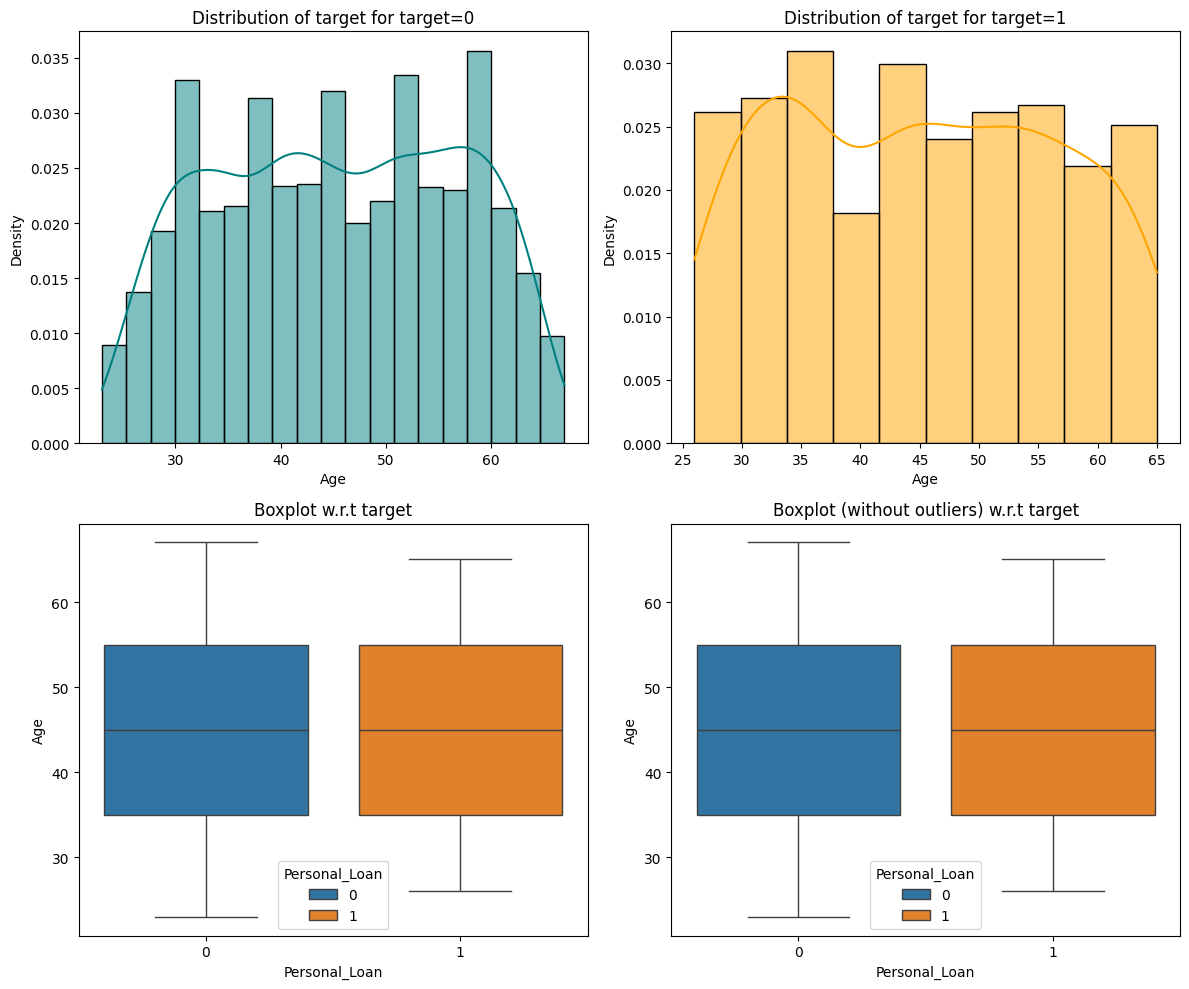

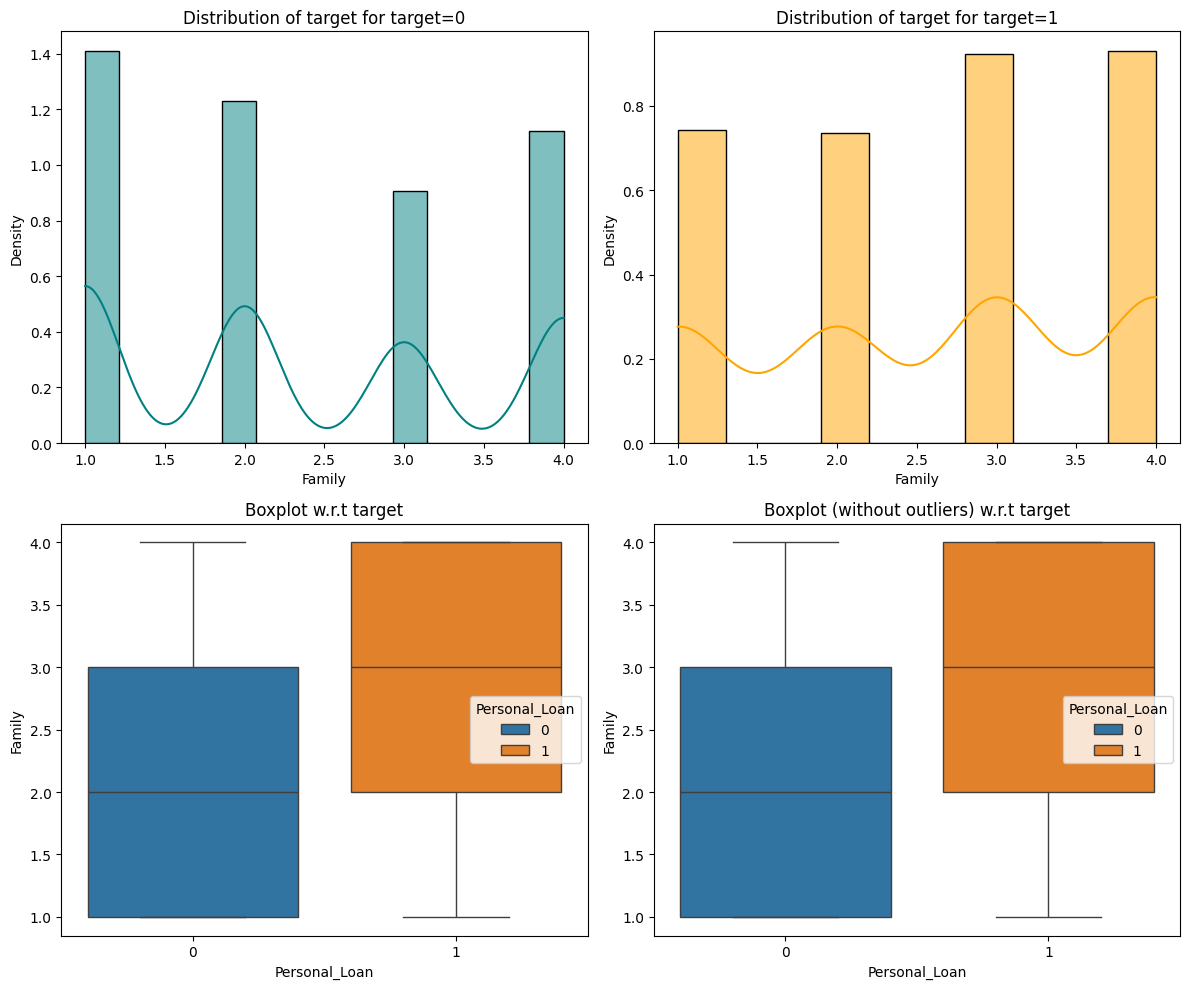

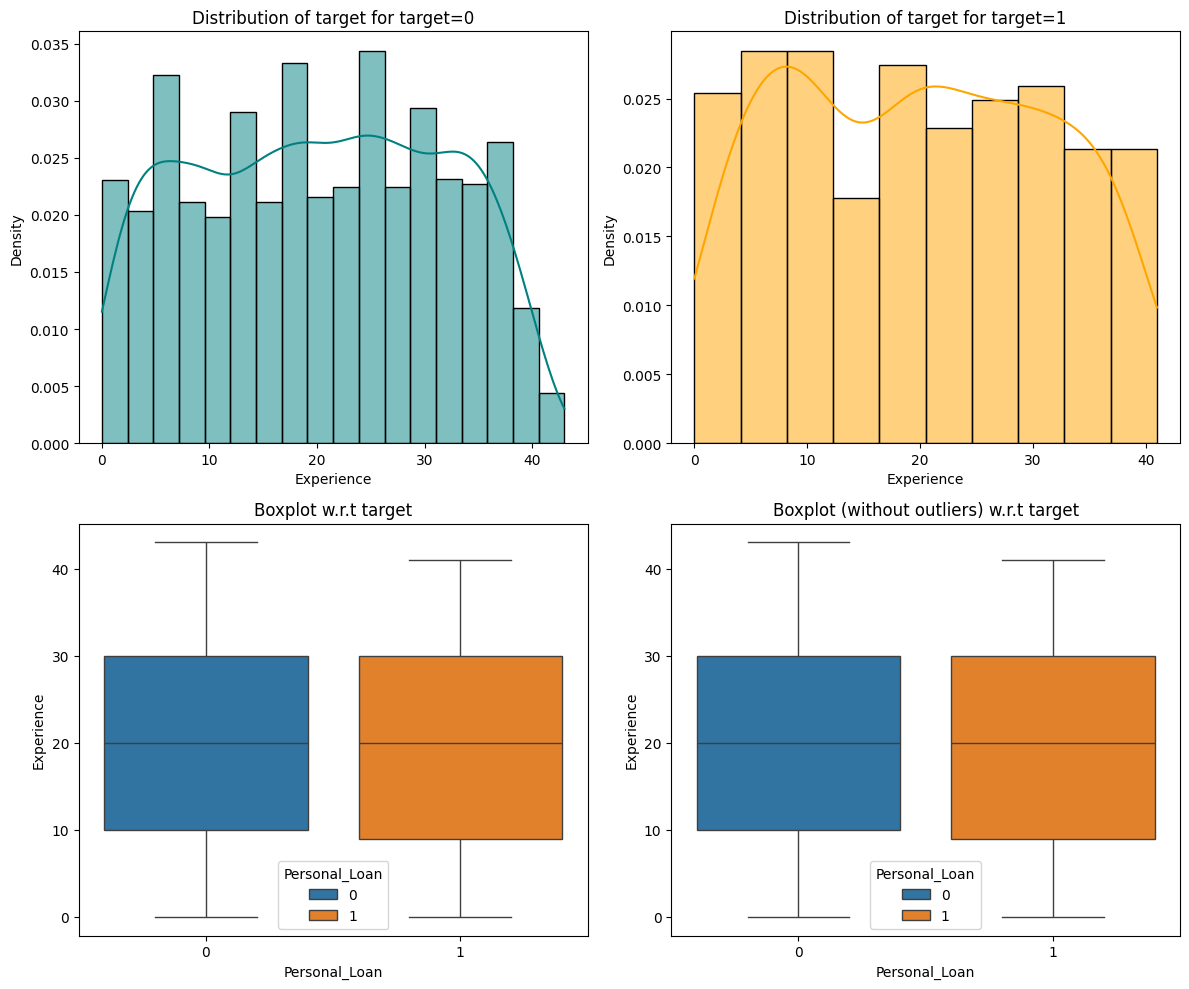

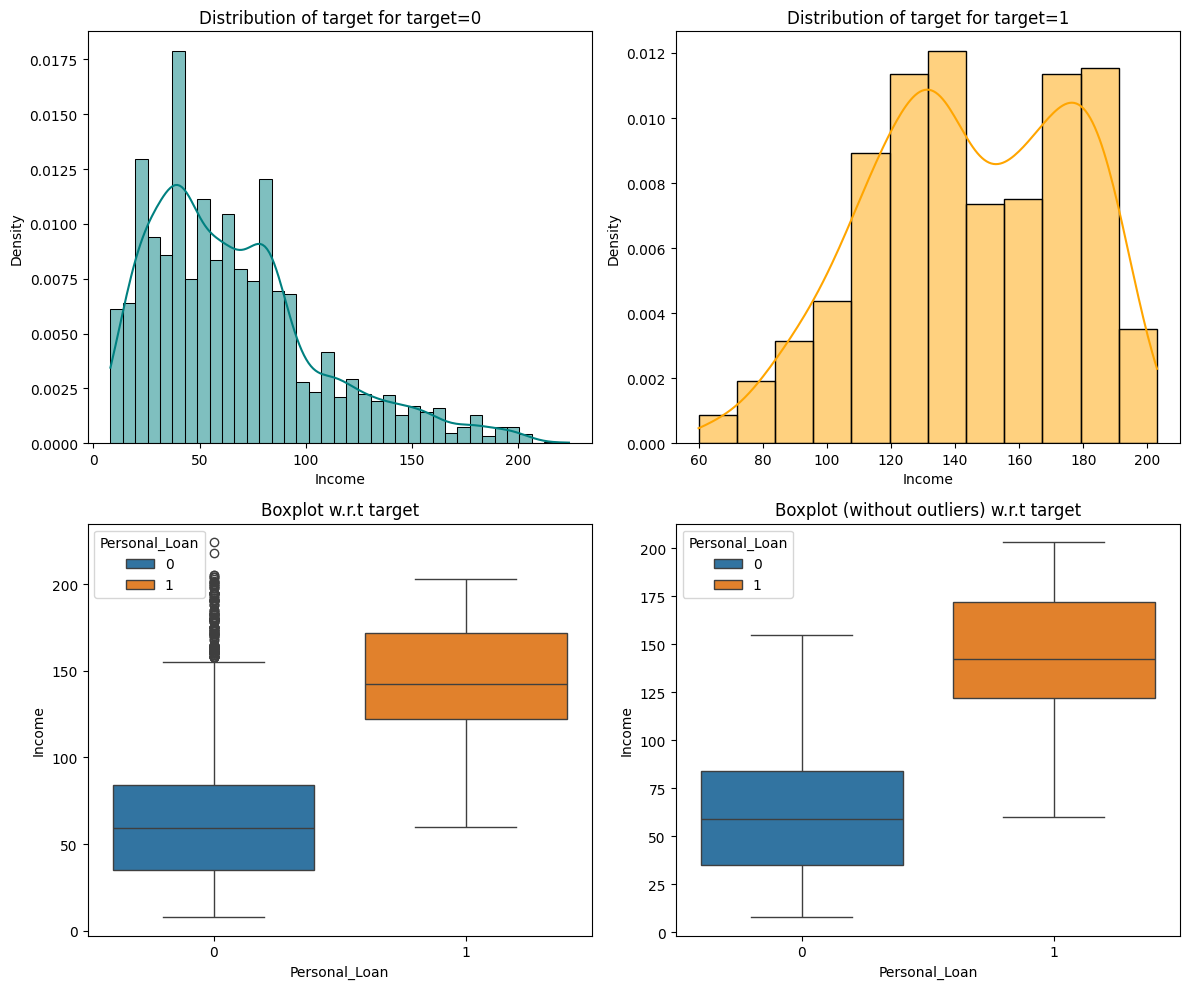

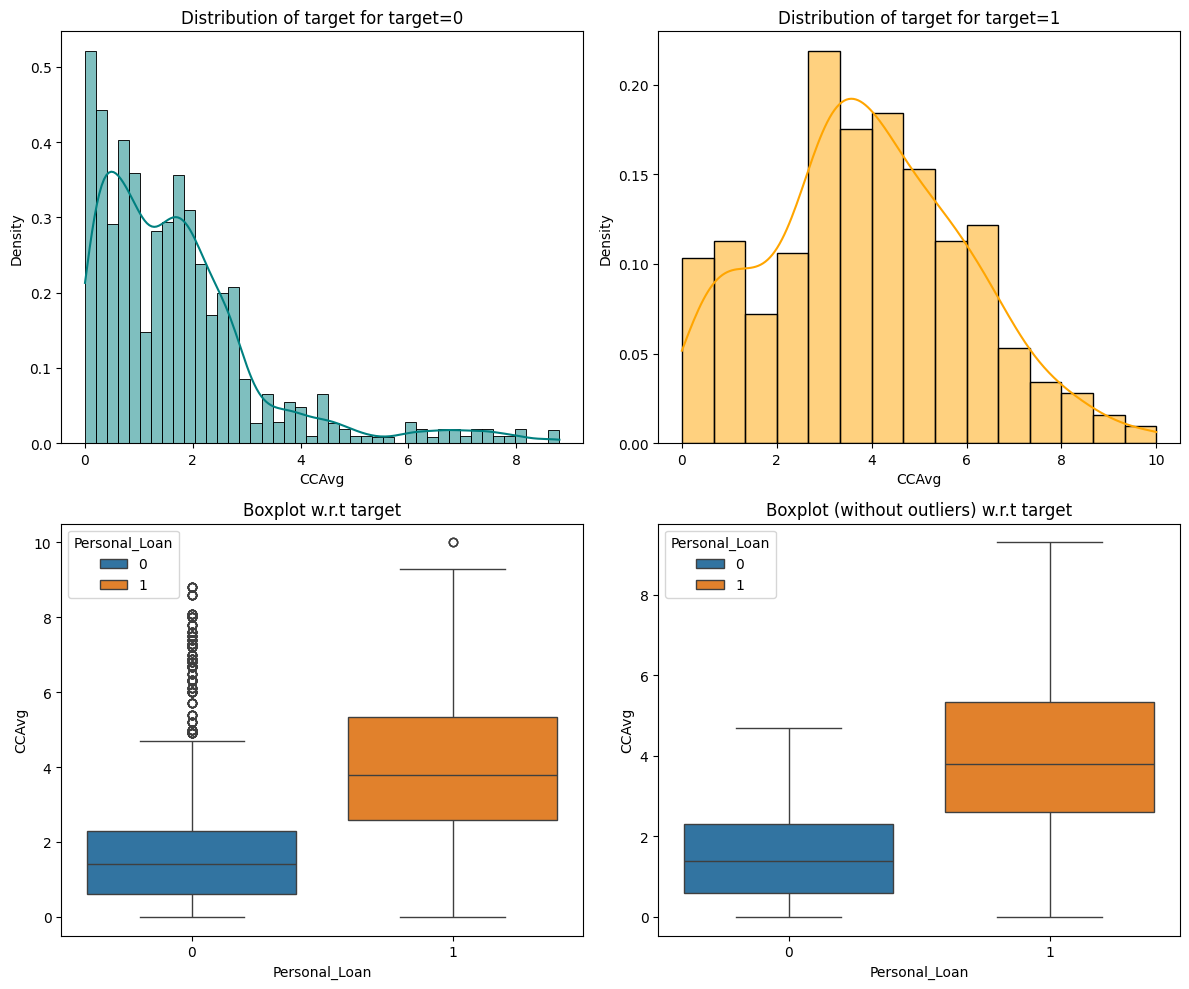

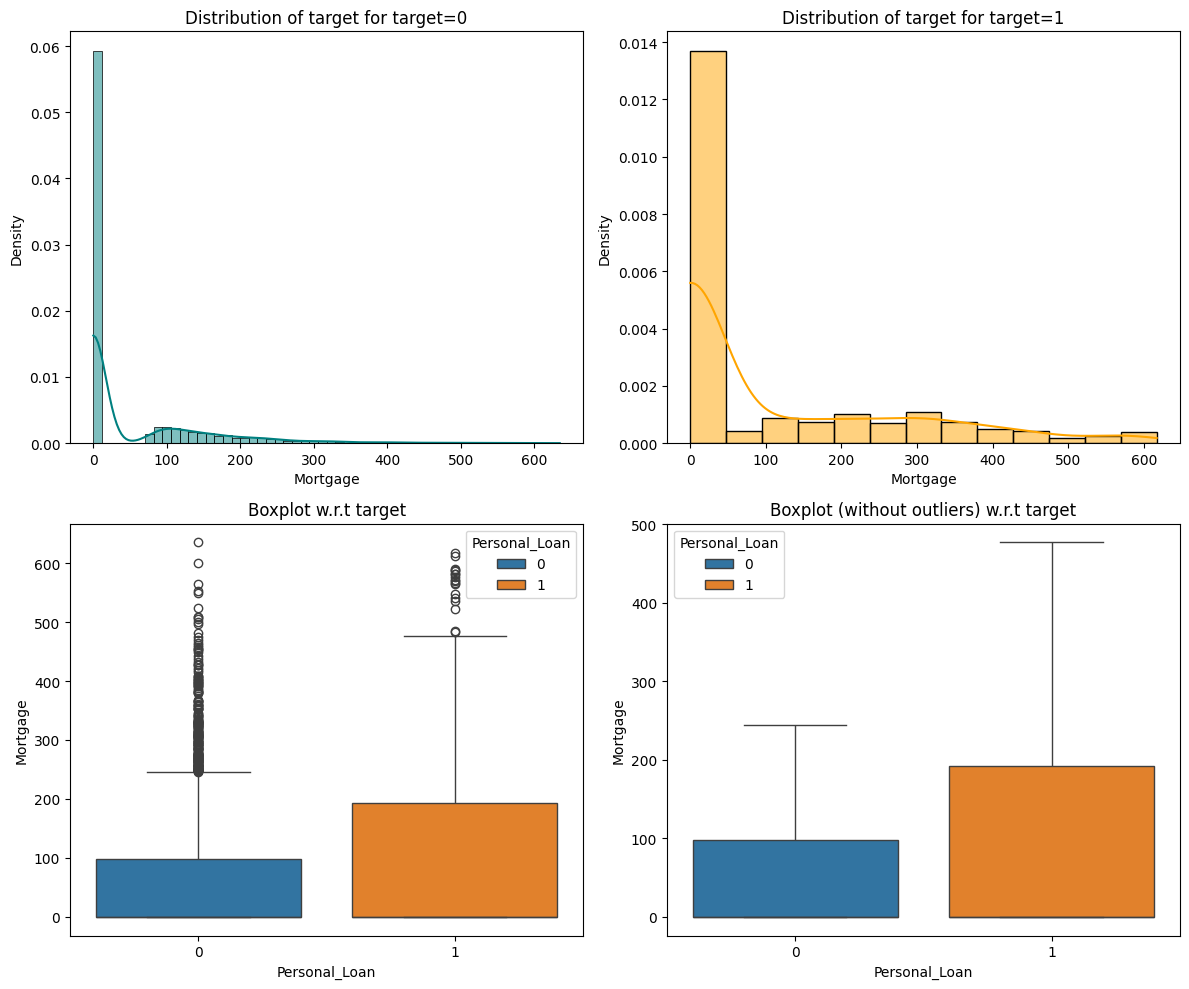

In [ ]:
for col in df_new[num_col]:
  distribution_plot_wrt_target(df_new, col, 'Personal_Loan')


#### **Observations**

*   Comparing age and experience of customers with loan and without loan their box plot reveals there is a overlap. Q1, mean and Q3 are similar for age while Q1 for experience is slightly lower for customers with loan but Q3 and mean are similar.
*   There is a clear indication that customers with higher income that is 115,000 to 195,000 are likely to get personal loans.
* Families that have more than 2 people are hight likely to be personal loan customers.
*   There is a clear indication that customers with higher credit card spending between 2500 to 6500 dollars are likely to get personal loans.
*   Customers who have mortgage less than 100 have lesser interest in personal loan




## Model Building

### Data Preparation for Modeling

In [ ]:
X = df_new.drop(["Personal_Loan"], axis=1)
Y = df_new["Personal_Loan"]

#X = pd.get_dummies(X, columns=['Education'],drop_first=True)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

I tried creating a model with dummies for Education feature. Pre pruning recall results were lower compared to untreated Education feature. Post pruning didn't pull up cc_alpha value and it was difficult to make out the value by referring recall vs alpha graph.

So I have proceeded by leaving education Feature as it is.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   Family              5000 non-null   int64   
 4   CCAvg               5000 non-null   float64 
 5   Education           5000 non-null   category
 6   Mortgage            5000 non-null   int64   
 7   Securities_Account  5000 non-null   category
 8   CD_Account          5000 non-null   category
 9   Online              5000 non-null   category
 10  CreditCard          5000 non-null   category
 11  ZIPCode_Mod         5000 non-null   category
dtypes: category(6), float64(1), int64(5)
memory usage: 266.9 KB


In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 12)
Shape of test set :  (1500, 12)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


We see that 90% of observations belongs to class 0 (Non loan customers) and 10% of observations belongs to class 1 (loan customers).

### Model Evaluation Criterion

**Needs of Bank:**

*   Whether a liability customer will buy personal loans.
*   Identify which customer attributes are most significant in driving purchases.
*   Identify which segment of customers to target.

The banks requirement on campaigning to a target customer pool who will become loan customers will be best addressed by **Decision Tree Classifier** model.

### Decision Tree

In [ ]:
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

**Model can make wrong predictions as:**

1. Predicting a customer will not buy personal loans but in reality the customer would buy loan (FN).

2. Predicting a customer will buy loan but in reality the customer would not buy loan (FP).


**Which case is more important?**

If we predict a customer will not buy personal loans but in reality the customer would buy loan then bank would lose an opportunity of providing loan to a potential customer.

**How to reduce this loss i.e need to reduce False Negatives?**

**recall** should be maximized, the greater the recall higher the chances of minimizing the false negatives.

### Model Building

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Checking model performance on train set

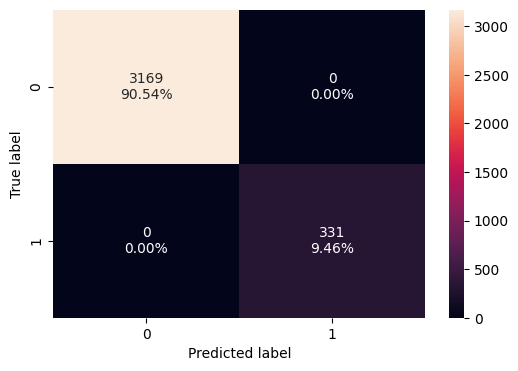

In [ ]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [ ]:
decision_tree_perf_train_without = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_perf_train_without

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


### Checking model performance on test set

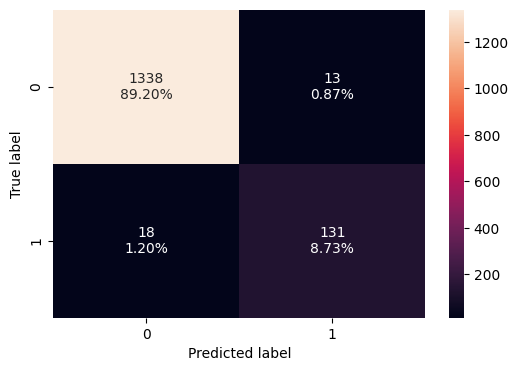

In [ ]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [ ]:
decision_tree_perf_test_without = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_perf_test_without

,Accuracy,Recall,Precision,F1
0,0.979333,0.879195,0.909722,0.894198


The performance results of model in train set indicates overfitting. This will affect test data performance. We need a generalized and train model with less tendency towards noise.

### Decision Tree (with class_weights and criterion)

 There is a chance that frequency of class become the dominant class and others a weak. This will make decision tree become biased toward the dominant classes. In this case, we will set class_weight = "balanced", which will automatically adjust the weights.

 We also set criterion as gini.

In [ ]:
model1 = DecisionTreeClassifier(criterion="gini",random_state=1, class_weight="balanced")
model1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

### Checking model performance on train set

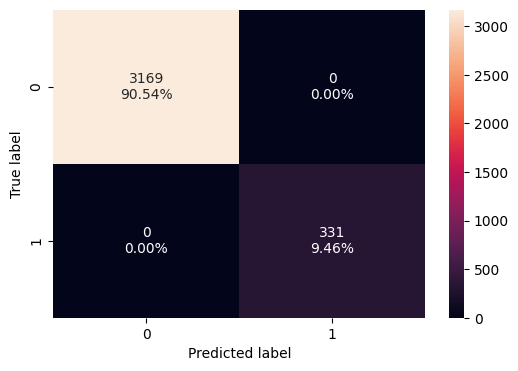

In [ ]:
confusion_matrix_sklearn(model1, X_train, y_train)

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_perf_train_without

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


### Checking model performance on test set

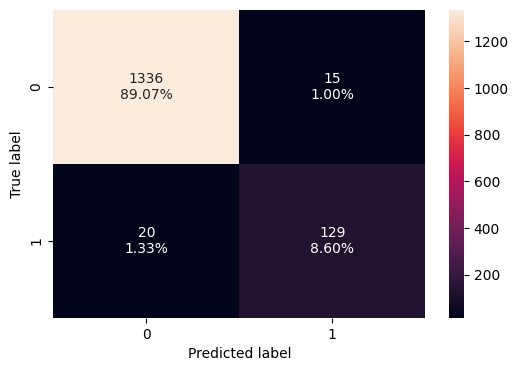

In [ ]:
confusion_matrix_sklearn(model1, X_test, y_test)

In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)
decision_tree_perf_test_without

,Accuracy,Recall,Precision,F1
0,0.979333,0.879195,0.909722,0.894198


Even after setting criterion and balancing the data, the performance results of model in train indicates overfitting and test scores remains the same.

### Visualizing the Decision Tree

In [ ]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'ZIPCode_Mod']


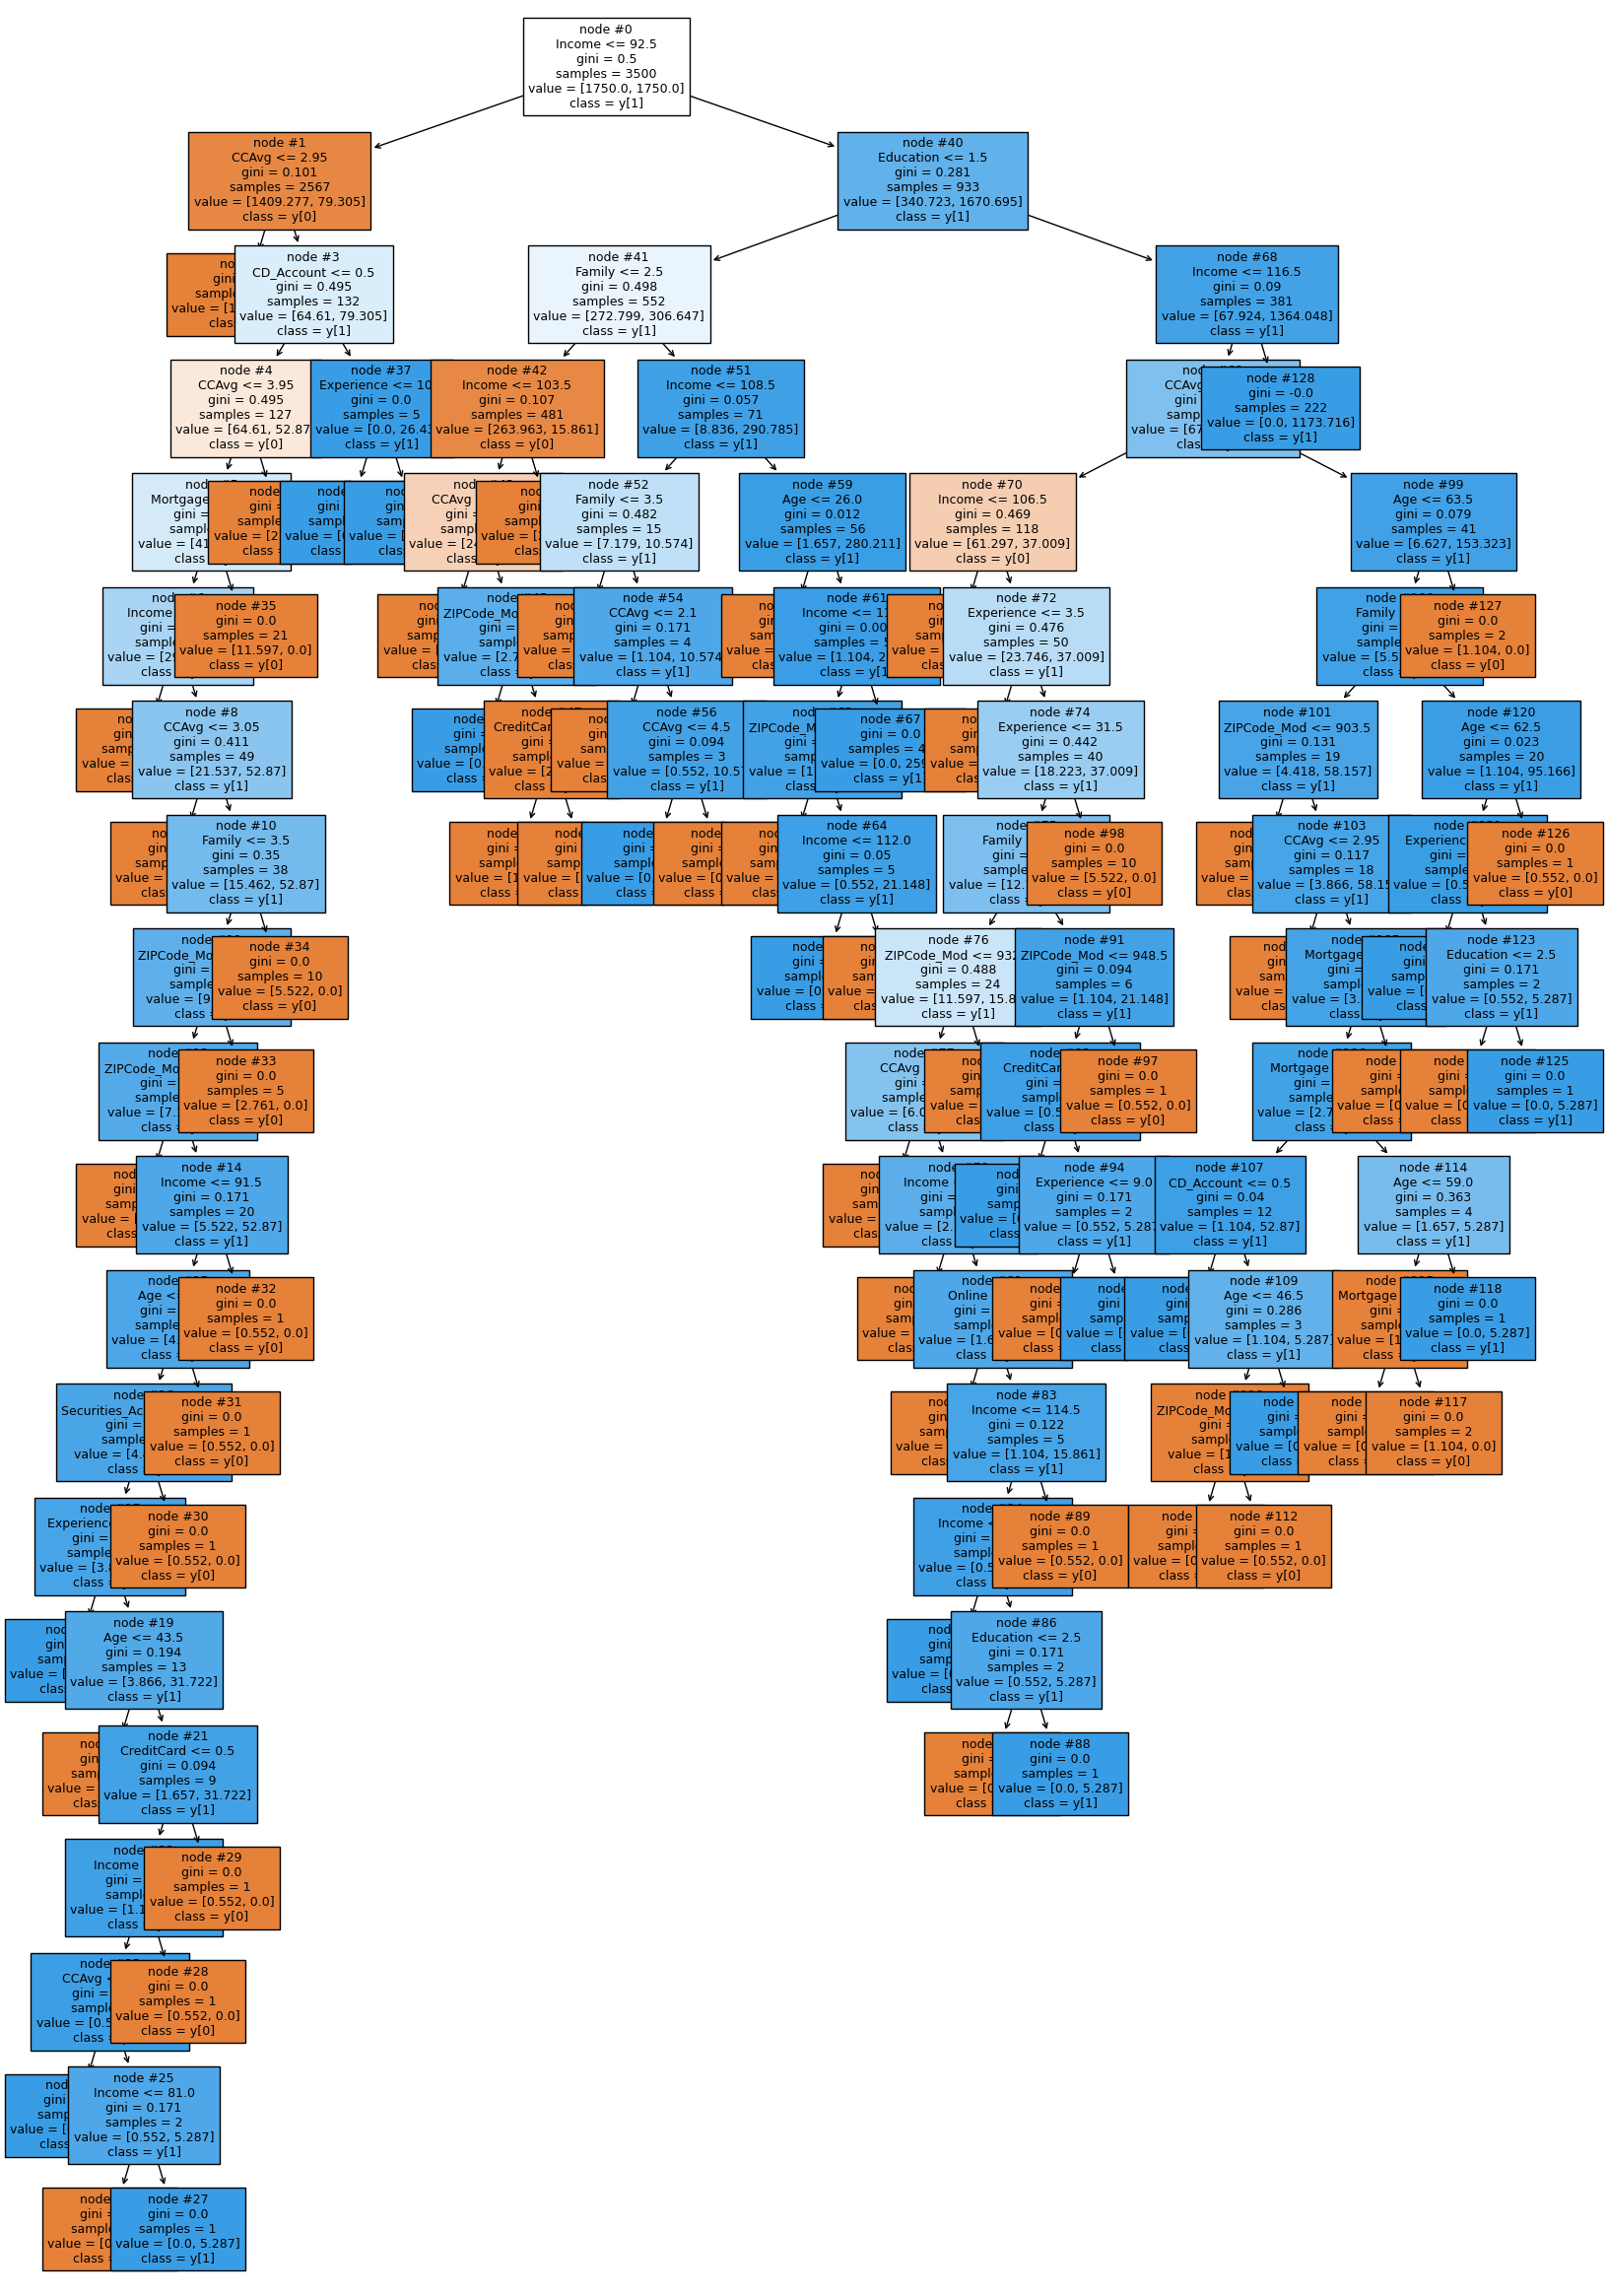

In [ ]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- Mortgage <= 102.50
|   |   |   |   |   |--- Income <= 68.50
|   |   |   |   |   |   |--- weights: [8.28, 0.00] class: 0
|   |   |   |   |   |--- Income >  68.50
|   |   |   |   |   |   |--- CCAvg <= 3.05
|   |   |   |   |   |   |   |--- weights: [6.07, 0.00] class: 0
|   |   |   |   |   |   |--- CCAvg >  3.05
|   |   |   |   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |   |   |   |--- ZIPCode_Mod <= 947.50
|   |   |   |   |   |   |   |   |   |--- ZIPCode_Mod <= 904.00
|   |   |   |   |   |   |   |   |   |   |--- weights: [1.66, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- ZIPCode_Mod >  904.00
|   |   |   |   |   |   |   |   |   |   |--- Income <= 91.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |   |   |   |   |   |   |---

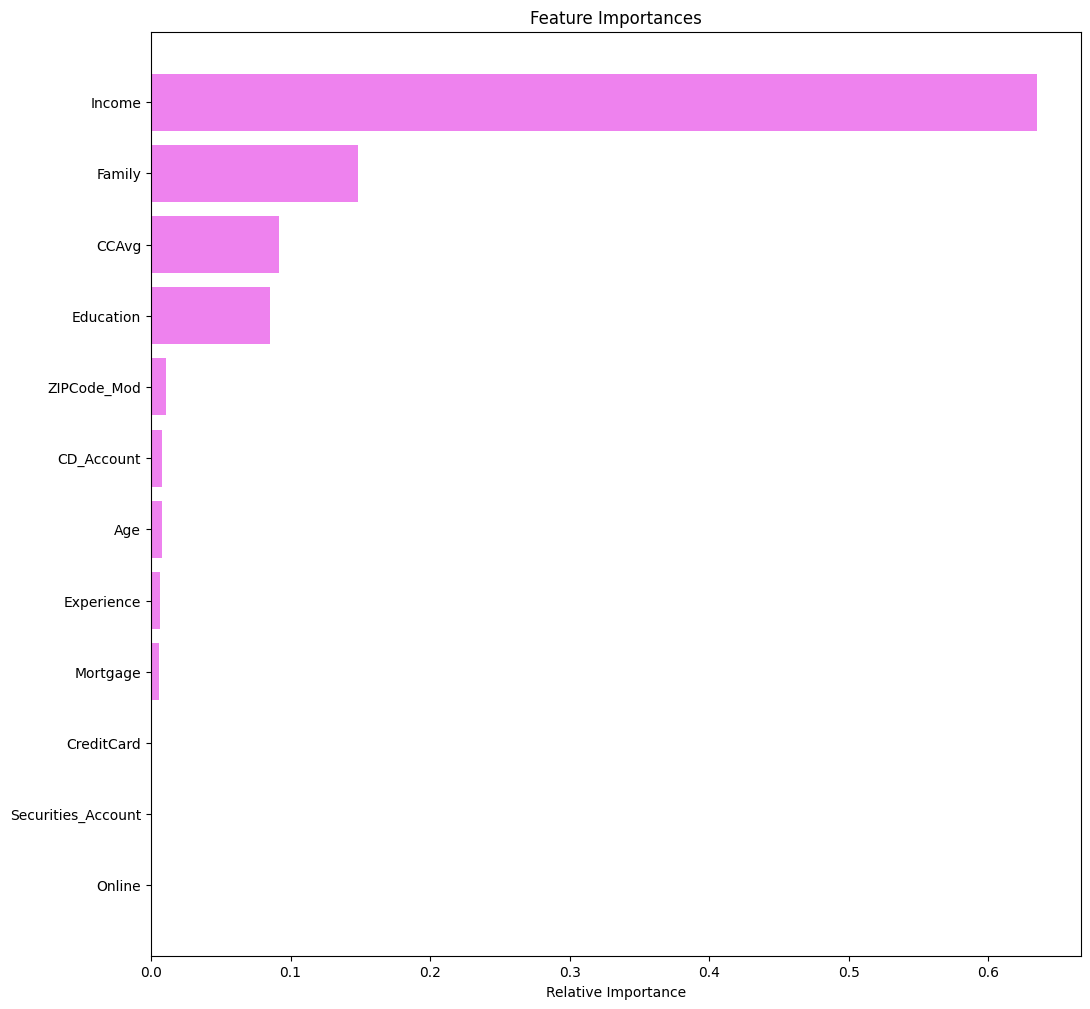

In [ ]:
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Income,  Family, CC_Avg and Education are top 4 important features.

### Model Performance Improvement

#### Using GridSearch for Hyperparameter tuning of our tree model
* Gridsearch allows us to run multiple compbinations of hyperparameters at the same time. By do this we can improve our model performance even more.

In [ ]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from

parameters = {
    "max_depth": np.arange(3, 13),
    "criterion": ["entropy", "gini"],
    #"splitter": ["best", "random",None],
    "class_weight": [None, "balanced"],
    'min_samples_leaf': [3, 5, 7, 10],
    'max_leaf_nodes' : [3, 5, 7, 10],
    "min_impurity_decrease": [0.00001,0.0001,0.001],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=3, max_leaf_nodes=5,
                       min_impurity_decrease=1e-05, min_samples_leaf=3,
                       random_state=1)

### Checking performance on training set

In [ ]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    estimator, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.926,0.990937,0.561644,0.71694


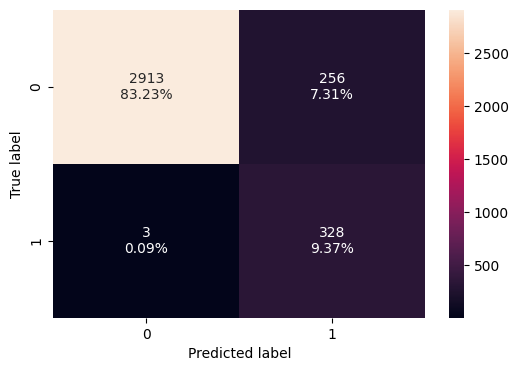

In [ ]:
confusion_matrix_sklearn(estimator, X_train, y_train)

### Checking model performance on test set

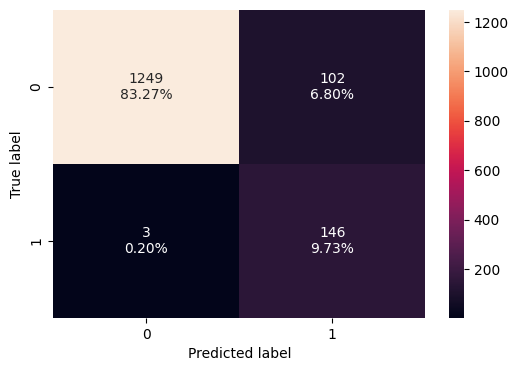

In [ ]:
confusion_matrix_sklearn(estimator, X_test, y_test)

In [ ]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)

decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.93,0.979866,0.58871,0.735516


The model is giving a better result now since the recall scores on both the train and test data are coming to be around 0.99 and 0.97 respectively. Still concerned about high recall score for train data which is close to overfitting.Overall the model is able to generalize well on unseen data but presicion and F1 score are taking a hit.

### Visualizing the Decision Tree with pre pruning

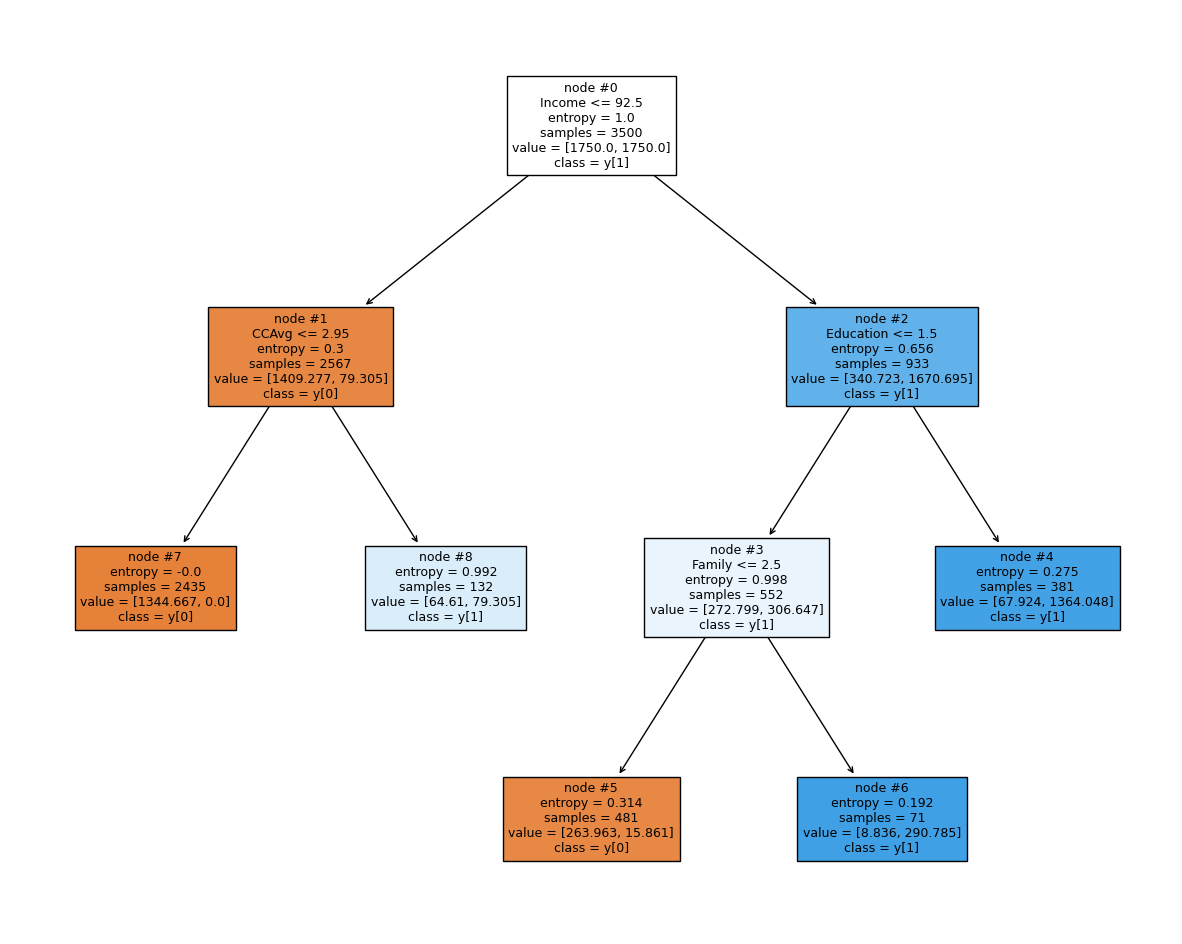

In [ ]:
plt.figure(figsize=(15, 12))

tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
plt.show()

#### **Observations**

Customers who have Income less than or equal to $92,500 and CC_Avg less than or equal to 2,950 are highly unlikely to apply for loan.

Cutomers who have income greater than $92,500 and are either graduates or advanced professionals are highly likey to get loans.

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- Mortgage <= 102.50
|   |   |   |   |   |--- Income <= 68.50
|   |   |   |   |   |   |--- weights: [8.28, 0.00] class: 0
|   |   |   |   |   |--- Income >  68.50
|   |   |   |   |   |   |--- CCAvg <= 3.05
|   |   |   |   |   |   |   |--- weights: [6.07, 0.00] class: 0
|   |   |   |   |   |   |--- CCAvg >  3.05
|   |   |   |   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |   |   |   |--- ZIPCode_Mod <= 947.50
|   |   |   |   |   |   |   |   |   |--- ZIPCode_Mod <= 904.00
|   |   |   |   |   |   |   |   |   |   |--- weights: [1.66, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- ZIPCode_Mod >  904.00
|   |   |   |   |   |   |   |   |   |   |--- Income <= 91.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |   |   |   |   |   |   |---

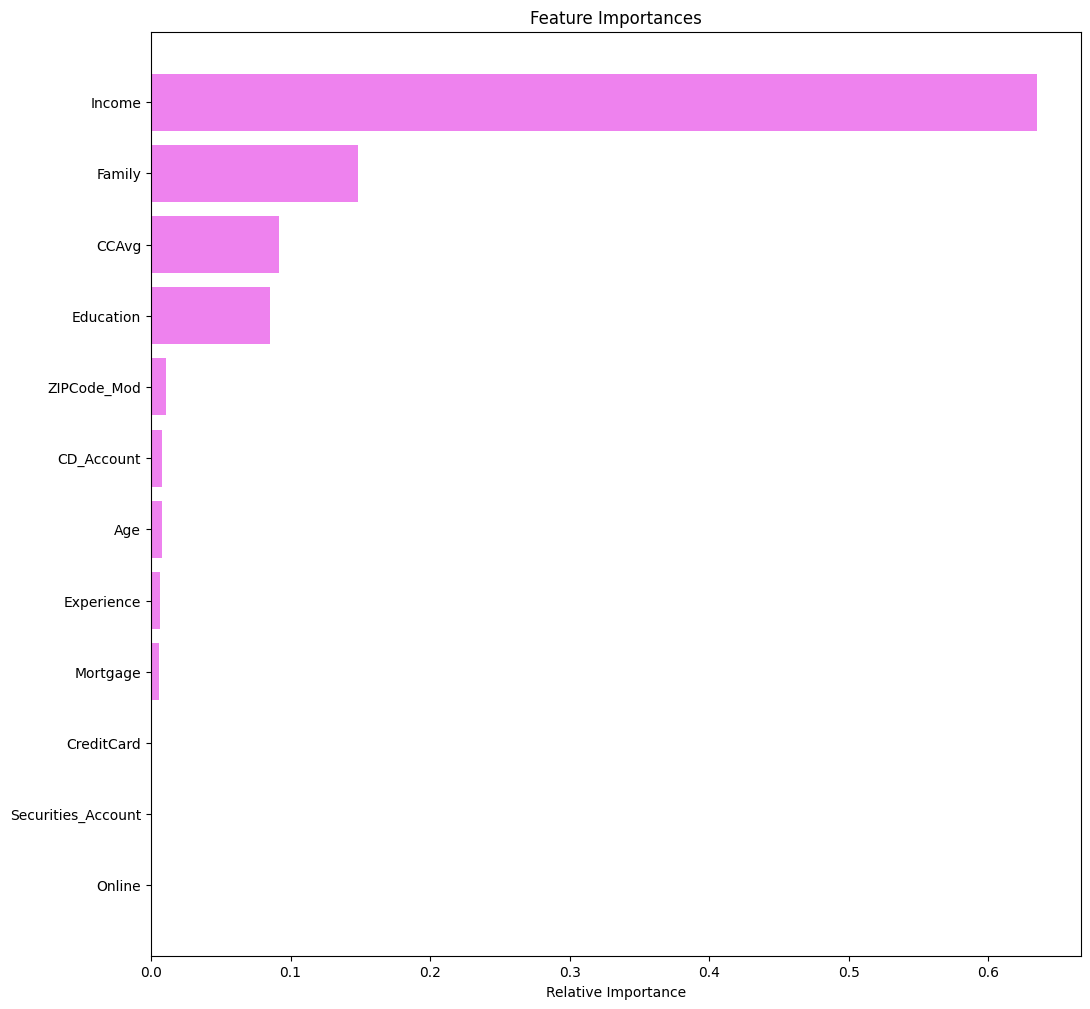

In [ ]:
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Income,  Family, CC_Avg and Education are top 4 important features.  The relative importance for Income is very high with value of 0.6

#### Post-Purning

#### Cost-Complexity Pruning

In [ ]:
clf = DecisionTreeClassifier(class_weight="balanced",random_state=1) # , class_weight="balanced" {0: 0.20, 1: 0.80}
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-7.288754e-15
1,3.853725e-19,-7.288369e-15
2,4.729571e-19,-7.287896e-15
3,1.051016e-18,-7.286845e-15
4,1.257806e-17,-7.274267e-15
5,1.524700e-04,3.049400e-04
6,1.537634e-04,6.124667e-04
7,1.550788e-04,9.226244e-04
8,1.568682e-04,1.236361e-03
9,2.095454e-04,1.864997e-03


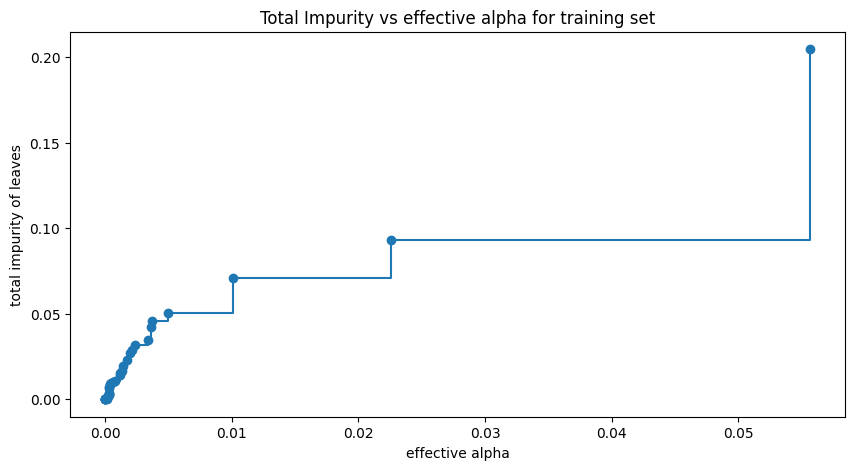

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.29537927599923175


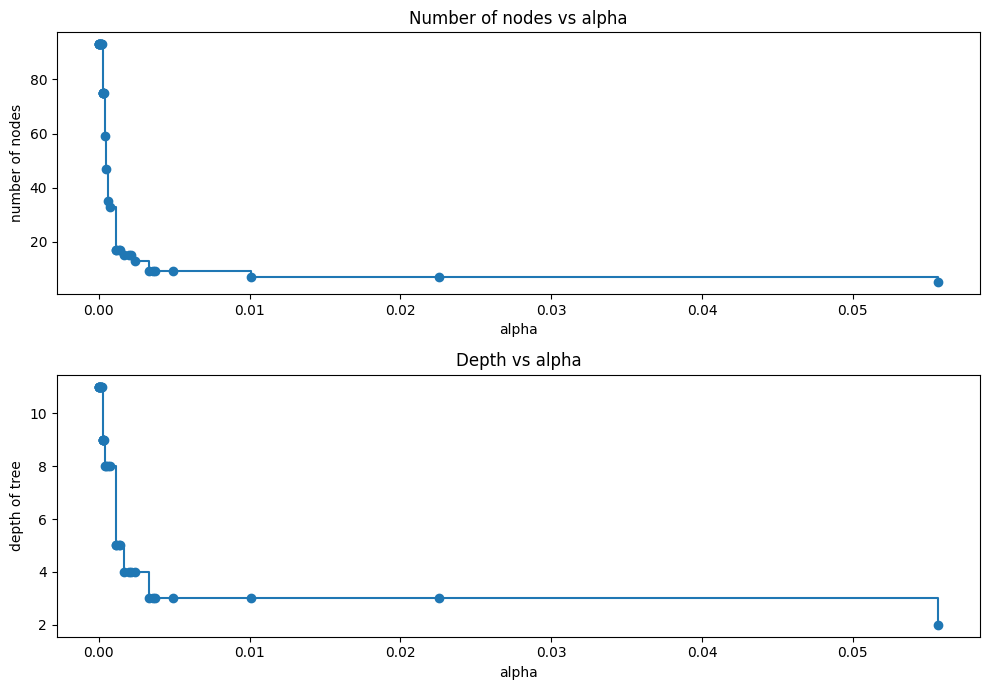

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

**Recall vs alpha for training and testing sets**

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
print(ccp_alphas)

[0.00000000e+00 3.85372460e-19 4.72957111e-19 1.05101580e-18
 1.25780554e-17 1.52470014e-04 1.53763358e-04 1.55078832e-04
 1.56868213e-04 2.09545385e-04 2.76101414e-04 2.85714286e-04
 2.92263357e-04 2.94763723e-04 3.03570014e-04 3.12470680e-04
 3.91491549e-04 4.86702332e-04 5.83935376e-04 7.54670551e-04
 1.15325820e-03 1.16931706e-03 1.34384519e-03 1.43109384e-03
 1.69374371e-03 1.98173011e-03 2.15041375e-03 2.37580862e-03
 3.34449290e-03 3.60293208e-03 3.72968952e-03 4.92087996e-03
 1.00780804e-02 2.25579227e-02 5.56478167e-02]


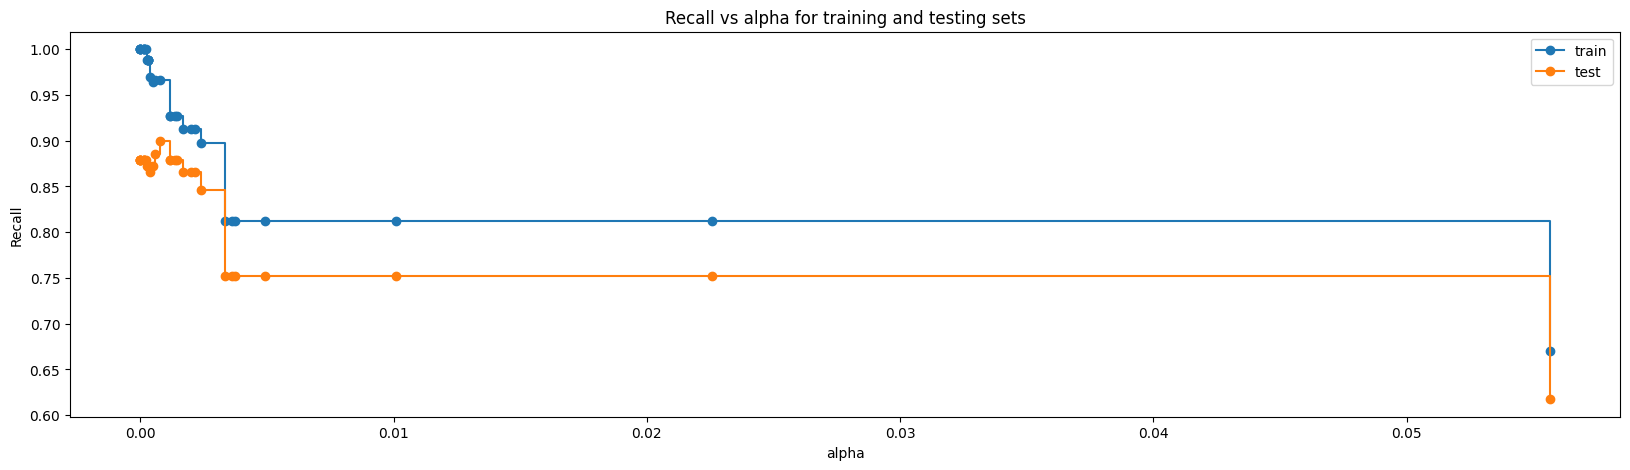

In [ ]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0007546705510198754, random_state=1)


**Checking performance on training data**

In [ ]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.992857,0.966767,0.958084,0.962406


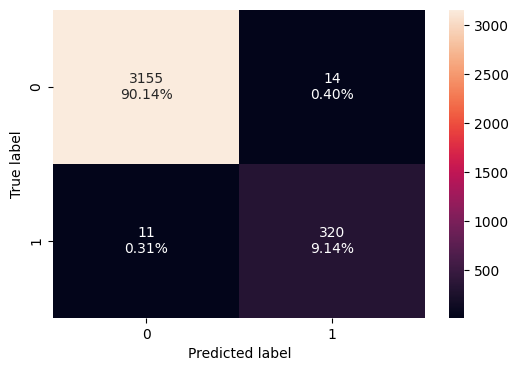

In [ ]:
confusion_matrix_sklearn(best_model, X_train, y_train)

**Checking performance on test data**

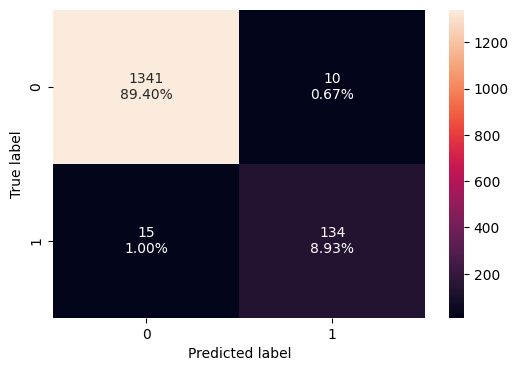

In [ ]:
confusion_matrix_sklearn(best_model, X_test, y_test)

In [ ]:
decision_tree_tune_post_test = model_performance_classification_sklearn(best_model, X_test, y_test)
decision_tree_tune_post_test

,Accuracy,Recall,Precision,F1
0,0.983333,0.899329,0.930556,0.914676


The model is giving a generalized result now since the recall scores on both the train and test data are coming to be around 0.96 and 0.89 respectively which shows that the model is able to generalize well on unseen data and presicion and F1 score are better when compared to pre-pruning.

**Visualizing the Decision Tree**

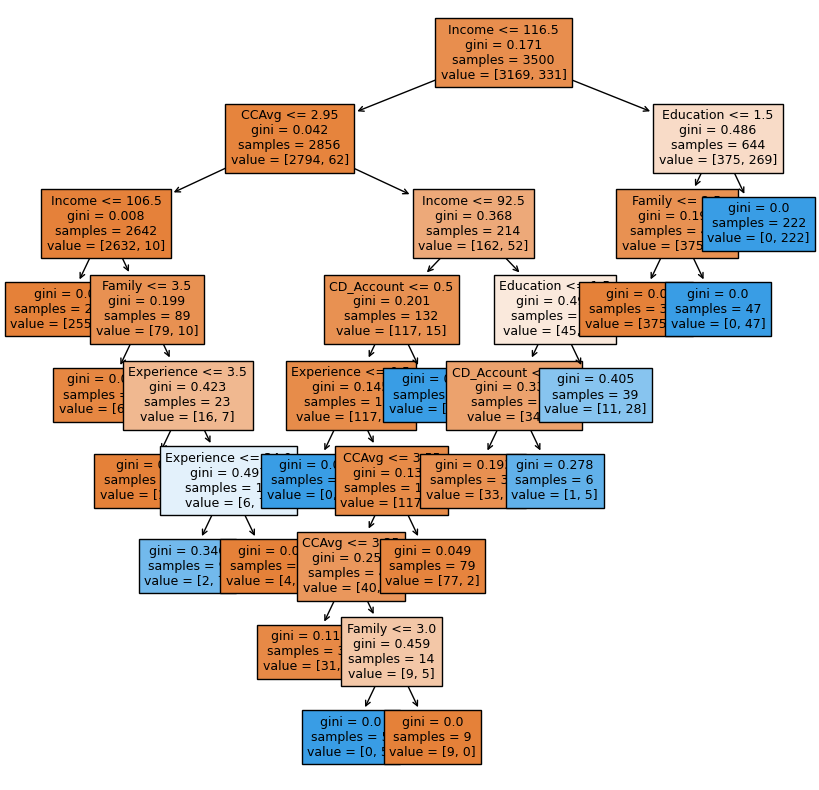

In [ ]:
plt.figure(figsize=(10, 10))
out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

#### **Observations**

Compared to pre-pruning method post-pruning decision tree seems more complex.

Customers who have Income less than or equal to $106,500 and CC_Avg less than or equal to 2,950 are highly unlikely to apply for loan.

Cutomers who have income greater than $116,500 and are either graduates or advanced professionals are highly likey to get loans.

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2553.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- weights: [63.00, 3.00] class: 0
|   |   |   |--- Family >  3.50
|   |   |   |   |--- Experience <= 3.50
|   |   |   |   |   |--- weights: [10.00, 0.00] class: 0
|   |   |   |   |--- Experience >  3.50
|   |   |   |   |   |--- Experience <= 34.00
|   |   |   |   |   |   |--- weights: [2.00, 7.00] class: 1
|   |   |   |   |   |--- Experience >  34.00
|   |   |   |   |   |   |--- weights: [4.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- Income <= 92.50
|   |   |   |--- CD_Account <= 0.50
|   |   |   |   |--- Experience <= 0.50
|   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- Experience >  0.50
|   |   |   |   |   |--- CCAvg <= 3.55
|   |   |   |   |   |   |--- CCAvg <= 3.35
|   |   |   |   |   |   |   |--- weights: [31.00, 2.00] class: 0
|   |   |

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        best_model.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Education           0.430462
Income              0.319735
Family              0.165225
CCAvg               0.045288
CD_Account          0.024353
Experience          0.014936
Age                 0.000000
Mortgage            0.000000
Securities_Account  0.000000
Online              0.000000
CreditCard          0.000000
ZIPCode_Mod         0.000000


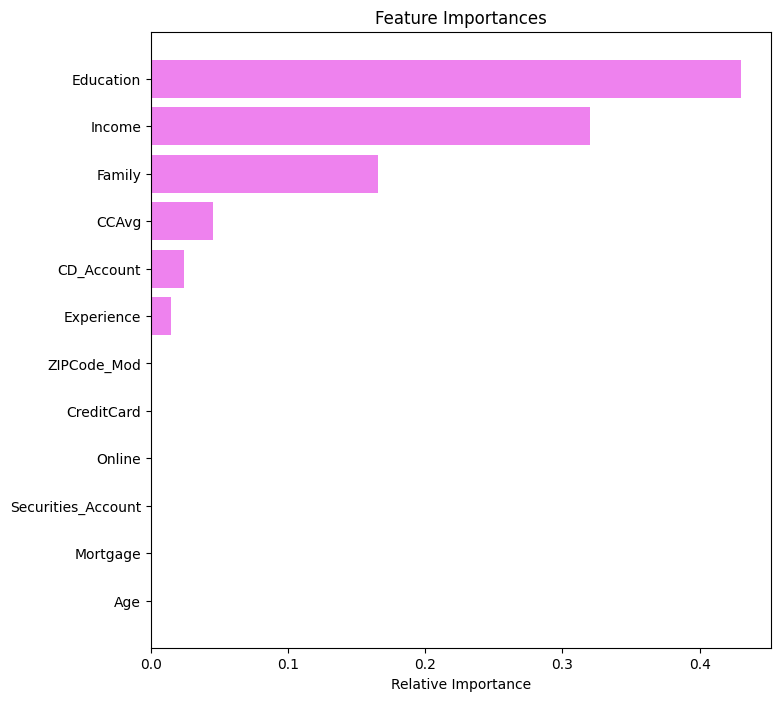

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Education, Income, Family and CC_Avg are top 4 important features. The relative importance of features are fairly distributed when compared to pre-prune model.

## Model Comparison and Final Model Selection

Income, Family, CC_Avg and Education are top 4 important features for ***pre pruning***.

Education, Income, Family and CC_Avg are top 4 important features for ***post pruning***.

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train_without.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree without class_weight",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree without class_weight,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.926000,0.992857
Recall,1.0,1.0,0.990937,0.966767
Precision,1.0,1.0,0.561644,0.958084
F1,1.0,1.0,0.716940,0.962406


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test_without.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_tune_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree without class_weight",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree without class_weight,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.979333,0.976667,0.930000,0.983333
Recall,0.879195,0.865772,0.979866,0.899329
Precision,0.909722,0.895833,0.588710,0.930556
F1,0.894198,0.880546,0.735516,0.914676


#### **Final Model**
Pre Pruning model gives best performance for recall however Post Pruning gives best overall performance with better F1 score. I suggest post pruning model for this problem.


## Actionable Insights and Business Recommendations


* The model correctly identify 89.9% of customers and can predict if an existing customer will purchase loan.

* Education, Income, Family and CC_Avg are important features for this model to predict if an existing customer will purchase loan.

* Our target cutomers are who have income greater than 116,500 and are either graduates or advanced professionals. Cutomers who have income greater than 116,500 and under graduates and Family size greater than 2.5 are highly likey to get loans.

* Campgain efforts should not be applied to Customers who have Income less than or equal to $106,500 and CC_Avg less than or equal to 2,950 are highly unlikely to apply for loan.

* Should the bank encounter marketing defecit and still would like to get customers apply for loan then we need to focus on precison score this will give higher ROI.

* Bank should keep track of loan defaulting customers. This information should be later included in model to give higher qualiy suggestion of customers who are likely to get loans but repay. This minimizes risk to bank significantly.

* Bank can also explore customers who will be interested in securities and CD account. This could create additional revenue stream.

___